In [18]:
%pip install matplotlib
%pip install pandas
%pip install requests
%pip install scipy
%pip install fastparquet





[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached fsspec-2026.6.0-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.4/717.4 kB 7.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.6 MB/s eta 0:00:00a 0:00:01
Using cached fsspec-2026.6.0-py3-non

In [19]:
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


# A: Data Prep


In [20]:
def find_package_root():
    direct_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in direct_candidates:
        if (candidate / "regression").exists() and (candidate / "data").exists():
            return candidate

    # Fallback for Jupyter sessions that start above the package root.
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents[:2]]
    seen = set()
    for search_root in search_roots:
        if search_root in seen or not search_root.exists():
            continue
        seen.add(search_root)
        for regression_nb in search_root.rglob("regression/regression_final.ipynb"):
            candidate = regression_nb.parent.parent
            if (candidate / "regression").exists() and (candidate / "data").exists():
                return candidate

    raise FileNotFoundError(
        "Could not locate the portable final_folder root. "
        "Expected a folder containing both 'regression' and 'data'."
    )

PACKAGE_ROOT = find_package_root()
REGRESSION_DIR = PACKAGE_ROOT / "regression"
DATA_DIR = PACKAGE_ROOT / "data"

DATA_DIR.mkdir(parents=True, exist_ok=True)

KPI_PATH = DATA_DIR / "kpis_final.parquet"
CLIMATE_PATH = DATA_DIR / "climate_zones.csv"
RUCA_PATH = DATA_DIR / "RUCA-codes-2020-tract.csv"
TECH_PATH = DATA_DIR / "technical_variables_parallel.parquet"
EV_PATH = DATA_DIR / "final_aggregated_fuel_stats.parquet"
COM_PV_PATH = DATA_DIR / "large_fp_update.pkl"
RES_PV_PATH = DATA_DIR / "pv_adoption_baseline.parquet"
HOUSEHOLDS_PATH = DATA_DIR / "Full_US_nb_households_df.parquet"

CACHE_CENSUS_PATH = DATA_DIR / "cache_census_acs_2022_tract.parquet"
CACHE_CENTROIDS_PATH = DATA_DIR / "cache_county_centroids.parquet"
CACHE_NASA_PATH = DATA_DIR / "cache_nasa_power_2022_county.parquet"
FINAL_OUTPUT_PATH = DATA_DIR / "regression_final.parquet"

REQUIRED_INPUT_PATHS = [
    KPI_PATH,
    CLIMATE_PATH,
    RUCA_PATH,
    TECH_PATH,
    EV_PATH,
    COM_PV_PATH,
    RES_PV_PATH,
    HOUSEHOLDS_PATH,
]
missing_inputs = [path for path in REQUIRED_INPUT_PATHS if not path.exists()]
if missing_inputs:
    raise FileNotFoundError(
        "Missing required input files in portable final_folder package:\n"
        + "\n".join(str(path.relative_to(PACKAGE_ROOT)) for path in missing_inputs)
    )

print(f"Portable package root: {PACKAGE_ROOT}")
print(f"Data dir: {DATA_DIR}")

CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY", "a604b4b19b543686b6c8cbad3ef66f58fe0e6003")
CENSUS_YEAR = "2022"
NASA_START = "20220101"
NASA_END = "20221231"
NASA_MAX_WORKERS = 2

STATE_FIPS_TO_ABBR = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA", "08": "CO", "09": "CT", "10": "DE", "11": "DC", "12": "FL", "13": "GA", "15": "HI", "16": "ID", "17": "IL", "18": "IN", "19": "IA", "20": "KS", "21": "KY", "22": "LA", "23": "ME", "24": "MD", "25": "MA", "26": "MI", "27": "MN", "28": "MS", "29": "MO", "30": "MT", "31": "NE", "32": "NV", "33": "NH", "34": "NJ", "35": "NM", "36": "NY", "37": "NC", "38": "ND", "39": "OH", "40": "OK", "41": "OR", "42": "PA", "44": "RI", "45": "SC", "46": "SD", "47": "TN", "48": "TX", "49": "UT", "50": "VT", "51": "VA", "53": "WA", "54": "WV", "55": "WI", "56": "WY"
}

INFERRED_DATE_RANK = {
    "": -1,
    "0-6 months": 0,
    "7-12 months": 1,
    "13-18 months": 2,
    "19-24 months": 3,
    "25-36 months": 4,
    "37-48 months": 5,
    "49+ months": 6,
}

CENSUS_RENAME_MAP = {
    "B19013_001E": "se_median_income",
    "B01002_001E": "se_median_age",
    "B01003_001E": "se_total_population",
    "B25010_001E": "se_avg_household_size",
    "B25003_001E": "total_households",
    "B25003_002E": "owner_occupied_households",
}
CENSUS_API_VARS = ",".join(CENSUS_RENAME_MAP.keys())

def format_fips(series, length):
    numeric = pd.to_numeric(series, errors="coerce")
    return numeric.astype("Int64").astype("string").str.zfill(length)

def ensure_unique(df, keys, name):
    duplicate_count = int(df.duplicated(subset=keys).sum())
    if duplicate_count:
        print(f"[warn] {name}: dropping {duplicate_count} duplicate rows on {keys}")
    return df.drop_duplicates(subset=keys, keep="last")

def load_parquet_cache(path, columns=None):
    if path.exists():
        return pd.read_parquet(path, columns=columns)
    return pd.DataFrame(columns=columns)

def save_deduped_cache(df, path, keys):
    if df.empty:
        return df
    deduped = ensure_unique(df, keys, path.name).sort_values(keys).reset_index(drop=True)
    deduped.to_parquet(path, index=False)
    return deduped

def get_json(url, timeout=30, max_retries=5, backoff_base=2.0, retry_statuses=None):
    if retry_statuses is None:
        retry_statuses = {429, 500, 502, 503, 504}

    last_error = None
    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=timeout)
            if response.status_code in retry_statuses:
                retry_after = response.headers.get("Retry-After")
                if retry_after is not None:
                    sleep_seconds = float(retry_after)
                else:
                    sleep_seconds = backoff_base ** attempt
                if attempt < max_retries - 1:
                    print(f"  [retry] status {response.status_code}; sleeping {sleep_seconds:.1f}s")
                    time.sleep(sleep_seconds)
                    continue
            response.raise_for_status()
            return response.json()
        except Exception as exc:
            last_error = exc
            if attempt >= max_retries - 1:
                break
            sleep_seconds = backoff_base ** attempt
            print(f"  [retry] request failed ({exc}); sleeping {sleep_seconds:.1f}s")
            time.sleep(sleep_seconds)
    raise last_error

def fetch_census_acs_tract(base_df, max_workers=8):
    desired = base_df[["state_fips", "county_code", "tract_code"]].drop_duplicates().rename(
        columns={"state_fips": "state", "county_code": "county", "tract_code": "tract"}
    )

    cached = load_parquet_cache(
        CACHE_CENSUS_PATH,
        columns=[
            "state",
            "county",
            "tract",
            "se_median_income",
            "se_median_age",
            "se_total_population",
            "se_avg_household_size",
            "se_homeownership_rate",
        ],
    )
    if not cached.empty:
        cached["state"] = format_fips(cached["state"], 2)
        cached["county"] = format_fips(cached["county"], 3)
        cached["tract"] = format_fips(cached["tract"], 6)
        acs_missing_sentinel = -666666666
        sentinel_cols = ["se_median_income", "se_median_age", "se_avg_household_size"]
        for col in sentinel_cols:
            if col in cached.columns:
                cached[col] = pd.to_numeric(cached[col], errors="coerce")
                cached.loc[cached[col] == acs_missing_sentinel, col] = np.nan

    merged = desired.merge(cached[["state", "county", "tract"]], on=["state", "county", "tract"], how="left", indicator=True)
    missing_states = sorted(merged.loc[merged["_merge"] == "left_only", "state"].dropna().unique())

    if missing_states:
        print(f"Census cache missing {len(missing_states)} states. Fetching only missing states...")

        def fetch_state(state_fips):
            url = (
                f"https://api.census.gov/data/{CENSUS_YEAR}/acs/acs5"
                f"?get={CENSUS_API_VARS}&for=tract:*&in=state:{state_fips}&key={CENSUS_API_KEY}"
            )
            payload = get_json(url, timeout=60)
            header, *rows = payload
            frame = pd.DataFrame(rows, columns=header)
            frame["state"] = format_fips(frame["state"], 2)
            frame["county"] = format_fips(frame["county"], 3)
            frame["tract"] = format_fips(frame["tract"], 6)
            return frame

        fetched_frames = []
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            future_map = {executor.submit(fetch_state, state): state for state in missing_states}
            for future in as_completed(future_map):
                state = future_map[future]
                try:
                    fetched_frames.append(future.result())
                    print(f"  fetched Census ACS for state {state}")
                except Exception as exc:
                    print(f"  [warn] Census fetch failed for state {state}: {exc}")

        if fetched_frames:
            fetched = pd.concat(fetched_frames, ignore_index=True)
            fetched = fetched.rename(columns=CENSUS_RENAME_MAP)
            numeric_cols = [
                "se_median_income",
                "se_median_age",
                "se_total_population",
                "se_avg_household_size",
                "total_households",
                "owner_occupied_households",
            ]
            for col in numeric_cols:
                fetched[col] = pd.to_numeric(fetched[col], errors="coerce")
            acs_missing_sentinel = -666666666
            sentinel_cols = ["se_median_income", "se_median_age", "se_avg_household_size"]
            for col in sentinel_cols:
                fetched.loc[fetched[col] == acs_missing_sentinel, col] = np.nan
            fetched["se_homeownership_rate"] = fetched["owner_occupied_households"] / fetched["total_households"]
            fetched = fetched[
                [
                    "state",
                    "county",
                    "tract",
                    "se_median_income",
                    "se_median_age",
                    "se_total_population",
                    "se_avg_household_size",
                    "se_homeownership_rate",
                ]
            ]
            cached = pd.concat([cached, fetched], ignore_index=True)
            cached = save_deduped_cache(cached, CACHE_CENSUS_PATH, ["state", "county", "tract"])
    else:
        print("Census cache already complete. No API calls needed.")

    census = desired.merge(cached, on=["state", "county", "tract"], how="left")
    census["tract_geoid"] = census["state"] + census["county"] + census["tract"]
    return census[
        [
            "tract_geoid",
            "se_median_income",
            "se_median_age",
            "se_total_population",
            "se_avg_household_size",
            "se_homeownership_rate",
        ]
    ]

def fetch_county_centroids(base_df, max_workers=16):
    desired = base_df[["county_geoid", "state_fips", "county_code"]].drop_duplicates()
    cached = load_parquet_cache(CACHE_CENTROIDS_PATH, columns=["county_geoid", "centroid_lat", "centroid_lon"])
    if not cached.empty:
        cached["county_geoid"] = format_fips(cached["county_geoid"], 5)

    missing = desired.loc[~desired["county_geoid"].isin(cached["county_geoid"]), ["county_geoid", "state_fips", "county_code"]]
    if not missing.empty:
        print(f"County centroid cache missing {len(missing)} counties. Fetching only missing counties...")

        def fetch_county(row):
            state_code = row.state_fips
            county_code = row.county_code
            url = (
                "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/State_County/MapServer/1/query"
                f"?where=STATE='{state_code}' AND COUNTY='{county_code}'&outFields=CENTLAT,CENTLON&f=json"
            )
            payload = get_json(url, timeout=30)
            features = payload.get("features", [])
            if not features:
                raise ValueError("no centroid returned")
            attrs = features[0]["attributes"]
            return {
                "county_geoid": row.county_geoid,
                "centroid_lat": pd.to_numeric(attrs.get("CENTLAT"), errors="coerce"),
                "centroid_lon": pd.to_numeric(attrs.get("CENTLON"), errors="coerce"),
            }

        new_rows = []
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            future_map = {executor.submit(fetch_county, row): row.county_geoid for row in missing.itertuples(index=False)}
            for future in as_completed(future_map):
                county_geoid = future_map[future]
                try:
                    new_rows.append(future.result())
                except Exception as exc:
                    print(f"  [warn] TIGERweb fetch failed for county {county_geoid}: {exc}")

        if new_rows:
            cached = pd.concat([cached, pd.DataFrame(new_rows)], ignore_index=True)
            cached = save_deduped_cache(cached, CACHE_CENTROIDS_PATH, ["county_geoid"])
    else:
        print("County centroid cache already complete. No API calls needed.")

    return cached

def fetch_nasa_power_metrics(base_df, centroids_df, max_workers=NASA_MAX_WORKERS, save_every=25):
    desired = base_df[["county_geoid"]].drop_duplicates().merge(centroids_df, on="county_geoid", how="left")
    fetchable = desired.dropna(subset=["centroid_lat", "centroid_lon"]).copy()
    cached = load_parquet_cache(
        CACHE_NASA_PATH,
        columns=[
            "county_geoid",
            "geo_mean_solar_irradiance",
            "geo_annual_hdd",
            "geo_annual_cdd",
            "geo_mean_temp_fluctuation",
        ],
    )
    if not cached.empty:
        cached["county_geoid"] = format_fips(cached["county_geoid"], 5)

    total_counties = len(fetchable)
    cached_counties = int(fetchable["county_geoid"].isin(cached["county_geoid"]).sum())
    missing = fetchable.loc[~fetchable["county_geoid"].isin(cached["county_geoid"]), ["county_geoid", "centroid_lat", "centroid_lon"]]
    print(f"NASA cache coverage before fetch: {cached_counties}/{total_counties} counties already cached")
    if cached_counties:
        print("Sample cached counties:", sorted(cached["county_geoid"].dropna().astype(str).unique())[:10])
    if not missing.empty:
        print("Sample missing counties:", missing["county_geoid"].astype(str).head(10).tolist())
        print(f"NASA cache missing {len(missing)} counties. Fetching only missing counties...")

        def fetch_county(row):
            url = (
                "https://power.larc.nasa.gov/api/temporal/daily/point"
                f"?parameters=ALLSKY_SFC_SW_DWN,T2M,T2M_MAX,T2M_MIN&community=RE&longitude={row.centroid_lon}"
                f"&latitude={row.centroid_lat}&start={NASA_START}&end={NASA_END}&format=JSON"
            )
            payload = get_json(url, timeout=60, max_retries=7, backoff_base=2.0)
            params = payload["properties"]["parameter"]
            daily = pd.DataFrame(
                {
                    "solar": pd.Series(params["ALLSKY_SFC_SW_DWN"], dtype="float64"),
                    "t2m": pd.Series(params["T2M"], dtype="float64"),
                    "tmax": pd.Series(params["T2M_MAX"], dtype="float64"),
                    "tmin": pd.Series(params["T2M_MIN"], dtype="float64"),
                }
            ).replace(-999, np.nan)

            return {
                "county_geoid": row.county_geoid,
                "geo_mean_solar_irradiance": daily["solar"].mean(),
                "geo_annual_hdd": (18.0 - daily.loc[daily["t2m"] < 18.0, "t2m"]).sum(),
                "geo_annual_cdd": (daily.loc[daily["t2m"] > 18.0, "t2m"] - 18.0).sum(),
                "geo_mean_temp_fluctuation": (daily["tmax"] - daily["tmin"]).mean(),
            }

        new_rows = []
        completed = 0
        try:
            with ThreadPoolExecutor(max_workers=max_workers) as executor:
                future_map = {executor.submit(fetch_county, row): row.county_geoid for row in missing.itertuples(index=False)}
                for future in as_completed(future_map):
                    county_geoid = future_map[future]
                    try:
                        new_rows.append(future.result())
                        completed += 1
                        print(f"  fetched {completed}/{len(missing)} missing NASA counties; latest={county_geoid}")
                        if completed % save_every == 0:
                            cached = pd.concat([cached, pd.DataFrame(new_rows)], ignore_index=True)
                            cached = save_deduped_cache(cached, CACHE_NASA_PATH, ["county_geoid"])
                            new_rows = []
                            cached_now = int(fetchable["county_geoid"].isin(cached["county_geoid"]).sum())
                            print(f"  saved NASA cache checkpoint after {completed} successful counties; cache now covers {cached_now}/{total_counties}")
                    except Exception as exc:
                        print(f"  [warn] NASA POWER fetch failed for county {county_geoid}: {exc}")
        finally:
            if new_rows:
                cached = pd.concat([cached, pd.DataFrame(new_rows)], ignore_index=True)
                cached = save_deduped_cache(cached, CACHE_NASA_PATH, ["county_geoid"])
                print(f"  flushed {len(new_rows)} unsaved NASA rows to cache")

        final_cached_counties = int(fetchable["county_geoid"].isin(cached["county_geoid"]).sum())
        print(f"NASA cache coverage after fetch: {final_cached_counties}/{total_counties} counties cached")
    else:
        print("NASA cache already complete. No API calls needed.")

    return cached


Portable package root: /Users/manu/Downloads/final_folder
Data dir: /Users/manu/Downloads/final_folder/data


## Outcome-Variable


In [ ]:
outcome = pd.read_parquet(KPI_PATH).copy()

outcome["county_geoid"] = format_fips(outcome["county"], 5)
outcome["tract_geoid"] = outcome["county_geoid"] + format_fips(outcome["tract"], 6)
outcome["state_fips"] = outcome["county_geoid"].str[:2]
outcome["county_code"] = outcome["county_geoid"].str[2:]
outcome["tract_code"] = outcome["tract_geoid"].str[5:]
outcome["state_abbr"] = outcome["state_fips"].map(STATE_FIPS_TO_ABBR)
outcome["state"] = outcome["state_abbr"]

outcome["out_peak"] = pd.to_numeric(
    outcome["peak_percent_reduction_opt_vs_no_battery_no_community_pv"],
    errors="coerce",
)
base_outage = pd.to_numeric(
    outcome["outage_no_battery_no_community_pv_outage_avg_uncovered_load_hours"],
    errors="coerce",
)
opt_outage = pd.to_numeric(
    outcome["outage_opt_outage_avg_uncovered_load_hours"],
    errors="coerce",
)
outcome["out_outages"] = np.where(base_outage > 0, (base_outage - opt_outage) / base_outage, np.nan)

base_df = outcome[
    [
        "county_geoid",
        "tract_geoid",
        "state",
        "state_fips",
        "state_abbr",
        "county_code",
        "tract_code",
        "out_peak",
        "out_outages",
    ]
].drop_duplicates(subset=["tract_geoid"]).copy()

print(f"Base rows: {len(base_df):,}")
print(f"Unique tracts: {base_df['tract_geoid'].nunique():,}")
base_df.head()


Base rows: 81,546
Unique tracts: 81,546


,county_geoid,tract_geoid,state,state_fips,state_abbr,county_code,tract_code,out_peak,out_outages
0,01003,01003010100,AL,01,AL,003,010100,4.748235,0.204753
1,01003,01003010200,AL,01,AL,003,010200,5.609333,0.202153
2,01003,01003010300,AL,01,AL,003,010300,6.546320,0.222454
3,01003,01003010400,AL,01,AL,003,010400,4.767366,0.240682
4,01003,01003010500,AL,01,AL,003,010500,8.255463,0.217792


## Socio-Economics


In [22]:
climate_zones = pd.read_csv(CLIMATE_PATH)
climate_zones["county_geoid"] = format_fips(climate_zones["State FIPS"], 2) + format_fips(climate_zones["County FIPS"], 3)
climate_features = ensure_unique(
    climate_zones[
        [
            "county_geoid",
            "BA Climate Zone",
        ]
    ].rename(
        columns={
            "BA Climate Zone": "geo_ba_climate_zone",
        }
    ),
    ["county_geoid"],
    "climate_features",
)

ruca = pd.read_csv(RUCA_PATH, encoding="latin1")
ruca["tract_geoid"] = format_fips(ruca["TractFIPS20"], 11)
ruca_features = ensure_unique(
    ruca[
        [
            "tract_geoid",
            "UrbanCoreType",
            "PopDensity",
        ]
    ].rename(
        columns={
            "UrbanCoreType": "se_urban_core_type",
            "PopDensity": "se_pop_density",
        }
    ),
    ["tract_geoid"],
    "ruca_features",
)

census_features = ensure_unique(fetch_census_acs_tract(base_df), ["tract_geoid"], "census_features")

socio_df = base_df[["tract_geoid"]].merge(census_features, on="tract_geoid", how="left").merge(ruca_features, on="tract_geoid", how="left")

print(socio_df.filter(regex=r"^se_").notna().sum().sort_index())
socio_df.head()

Census cache already complete. No API calls needed.
se_avg_household_size    81514
se_homeownership_rate    81546
se_median_age            81524
se_median_income         81110
se_pop_density           81546
se_total_population      81546
se_urban_core_type       81546
dtype: int64


,tract_geoid,se_median_income,se_median_age,se_total_population,se_avg_household_size,se_homeownership_rate,se_urban_core_type,se_pop_density
0,01003010100,54156.0,47.7,3628,2.75,0.884645,Rural,10.0
1,01003010200,50368.0,41.1,2955,2.46,0.705686,Rural,35.0
2,01003010300,75905.0,40.6,8740,2.79,0.897251,Rural,63.3
3,01003010400,55697.0,46.8,5730,2.66,0.895862,Rural,20.1
4,01003010500,58026.0,39.6,5291,2.46,0.789979,Small town core,720.9


## Geografic


In [23]:
county_centroids = fetch_county_centroids(base_df)
nasa_features = ensure_unique(fetch_nasa_power_metrics(base_df, county_centroids), ["county_geoid"], "nasa_features")

geo_df = (
    base_df[["tract_geoid", "county_geoid"]]
    .merge(climate_features, on="county_geoid", how="left")
    .merge(nasa_features, on="county_geoid", how="left")
    .assign(
        geo_annual_degree_days=lambda df_: df_[["geo_annual_hdd", "geo_annual_cdd"]].sum(axis=1, min_count=2)
    )
    .drop(columns=["county_geoid", "geo_annual_hdd", "geo_annual_cdd"])
)

print(geo_df.filter(regex=r"^geo_").notna().sum().sort_index())
geo_df.head()


County centroid cache already complete. No API calls needed.
NASA cache coverage before fetch: 3097/3097 counties already cached
Sample cached counties: ['01001', '01003', '01005', '01007', '01009', '01011', '01013', '01015', '01017', '01019']
NASA cache already complete. No API calls needed.
geo_annual_degree_days       81546
geo_ba_climate_zone          81546
geo_mean_solar_irradiance    81546
geo_mean_temp_fluctuation    81546
dtype: int64


,tract_geoid,geo_ba_climate_zone,geo_mean_solar_irradiance,geo_mean_temp_fluctuation,geo_annual_degree_days
0,01003010100,Hot-Humid,4.921992,8.333781,2353.61
1,01003010200,Hot-Humid,4.921992,8.333781,2353.61
2,01003010300,Hot-Humid,4.921992,8.333781,2353.61
3,01003010400,Hot-Humid,4.921992,8.333781,2353.61
4,01003010500,Hot-Humid,4.921992,8.333781,2353.61


## Tech


In [24]:
ev_adoption = pd.read_parquet(EV_PATH)
ev_adoption["tract_code"] = format_fips(ev_adoption["CENSUSTRACT"], 6)
ev_adoption = ev_adoption[ev_adoption["INFERREDDATE"].notna() & (ev_adoption["INFERREDDATE"] != "")].copy()
fuel_columns = [col for col in ev_adoption.columns if col not in ["CENSUSTRACT", "STATE", "INFERREDDATE", "tract_code"]]
for col in fuel_columns:
    ev_adoption[col] = pd.to_numeric(ev_adoption[col], errors="coerce").fillna(0)
ev_grouped = ev_adoption.groupby(["STATE", "tract_code"], as_index=False)[fuel_columns].sum()
ev_grouped["total_ev"] = ev_grouped["Plug-in electric"]
ev_grouped["total_vehicles"] = ev_grouped[fuel_columns].sum(axis=1)
ev_grouped["tech_ev_share"] = np.where(ev_grouped["total_vehicles"] > 0, ev_grouped["total_ev"] / ev_grouped["total_vehicles"], 0.0)
ev_features = ensure_unique(
    ev_grouped[["STATE", "tract_code", "tech_ev_share"]].rename(columns={"STATE": "state_abbr"}),
    ["state_abbr", "tract_code"],
    "ev_features",
)

com_pv = pd.read_pickle(COM_PV_PATH).reset_index().rename(
    columns={
        "GEOID": "tract_geoid",
        "count": "tech_community_pv_site_count",
        "sum": "tech_community_pv_area_m2",
    }
)
if "tract_geoid" not in com_pv.columns:
    com_pv = com_pv.rename(columns={com_pv.columns[0]: "tract_geoid"})
com_pv["tract_geoid"] = com_pv["tract_geoid"].astype("string").str.zfill(11)
com_pv_features = ensure_unique(
    com_pv[["tract_geoid", "tech_community_pv_site_count", "tech_community_pv_area_m2"]],
    ["tract_geoid"],
    "com_pv_features",
)

households = pd.read_parquet(HOUSEHOLDS_PATH)
households["tract_geoid"] = format_fips(households["tract"], 11)
households["nb_households"] = pd.to_numeric(households["nb_households"], errors="coerce")
households_features = ensure_unique(
    households[["tract_geoid", "nb_households"]],
    ["tract_geoid"],
    "households_features",
)

res_pv = pd.read_parquet(RES_PV_PATH, columns=["tract", "pv_adoption"])
res_pv["tract_geoid"] = format_fips(res_pv["tract"], 11)
res_pv_features = ensure_unique(
    res_pv[["tract_geoid", "pv_adoption"]].rename(
        columns={
            "pv_adoption": "tech_res_pv_adoption",
        }
    ),
    ["tract_geoid"],
    "res_pv_features",
)

tech_variables = pd.read_parquet(TECH_PATH)
tech_variables["county_geoid"] = format_fips(tech_variables["county_geoid"], 5)
tech_variables["tract_geoid"] = tech_variables["county_geoid"] + format_fips(tech_variables["tract_geoid"], 6)
tech_features = ensure_unique(
    tech_variables[
        [
            "tract_geoid",
            "annual_expected_outage_events_saifi",
            "annual_expected_outage_hours_saidi",
            "average_outage_duration_hours_caidi",
            "annual_total_load_kwh",
            "daily_average_load_kwh",
            "daily_average_peak_kwh",
            "peakiness",
            "commercial_load_share",
            "essential_load_share",
            "baseline_battery_kwh",
            "battery_load_ratio",
        ]
    ].rename(
        columns={
            "annual_expected_outage_events_saifi": "tech_saifi",
            "annual_expected_outage_hours_saidi": "tech_saidi",
            "average_outage_duration_hours_caidi": "tech_caidi",
            "annual_total_load_kwh": "tech_total_load",
            "daily_average_load_kwh": "tech_daily_load",
            "daily_average_peak_kwh": "tech_daily_peak",
            "peakiness": "tech_peakiness",
            "commercial_load_share": "tech_commercial_load_share",
            "essential_load_share": "tech_essential_load_share",
            "baseline_battery_kwh": "tech_baseline_battery_kwh",
            "battery_load_ratio": "tech_battery_load_ratio",
        }
    ),
    ["tract_geoid"],
    "tech_features",
)

tech_df = (
    base_df[["tract_geoid", "state_abbr", "tract_code"]]
    .merge(ev_features, on=["state_abbr", "tract_code"], how="left")
    .merge(com_pv_features, on="tract_geoid", how="left")
    .merge(households_features, on="tract_geoid", how="left")
    .merge(res_pv_features, on="tract_geoid", how="left")
    .merge(tech_features, on="tract_geoid", how="left")
    .drop(columns=["state_abbr", "tract_code"])
)

tech_df["tech_community_pv_area_m2_by_household"] = np.where(
    tech_df["nb_households"] > 0,
    tech_df["tech_community_pv_area_m2"] / tech_df["nb_households"],
    np.nan,
)
tech_df["tech_daily_peak_per_household"] = np.where(
    tech_df["nb_households"] > 0,
    tech_df["tech_daily_peak"] / tech_df["nb_households"],
    np.nan,
)
tech_df = tech_df.drop(columns=["nb_households"])

print(tech_df.filter(regex=r"^tech_").notna().sum().sort_index())
tech_df.head()


tech_baseline_battery_kwh                 81546
tech_battery_load_ratio                   81546
tech_caidi                                81546
tech_commercial_load_share                81546
tech_community_pv_area_m2                 80729
tech_community_pv_area_m2_by_household    80729
tech_community_pv_site_count              80729
tech_daily_load                           81546
tech_daily_peak                           81546
tech_daily_peak_per_household             81546
tech_essential_load_share                 81546
tech_ev_share                             81394
tech_peakiness                            81546
tech_res_pv_adoption                      81546
tech_saidi                                81546
tech_saifi                                81546
tech_total_load                           81546
dtype: int64


,tract_geoid,tech_ev_share,tech_community_pv_site_count,tech_community_pv_area_m2,tech_res_pv_adoption,tech_saifi,tech_saidi,tech_caidi,tech_total_load,tech_daily_load,tech_daily_peak,tech_peakiness,tech_commercial_load_share,tech_essential_load_share,tech_baseline_battery_kwh,tech_battery_load_ratio,tech_community_pv_area_m2_by_household,tech_daily_peak_per_household
0,01003010100,0.0,13.0,25441.054022,0.0,1.708035,5.50177,3.22111,1.525633e+07,41798.154773,708.318655,4.261340,0.068927,0.717488,1309.0,0.031317,19.585107,0.545280
1,01003010200,0.0,12.0,22213.252224,0.0,1.708035,5.50177,3.22111,1.455590e+07,39879.175267,665.847650,4.663258,0.041079,0.715801,1196.0,0.029991,18.937129,0.567645
2,01003010300,0.0,46.0,275684.143800,0.0,1.708035,5.50177,3.22111,4.876014e+07,133589.433462,2074.159840,3.838173,0.279824,0.558118,2910.0,0.021783,91.407209,0.687719
3,01003010400,0.0,54.0,296736.568950,0.0,1.708035,5.50177,3.22111,4.721541e+07,129357.288300,1862.228473,3.296968,0.443287,0.409714,2151.0,0.016628,133.785649,0.839598
4,01003010500,0.0,48.0,135132.579896,0.0,1.708035,5.50177,3.22111,3.940091e+07,107947.690117,1631.047576,3.409113,0.509367,0.466305,1876.0,0.017379,73.401727,0.885957


## Normalization

# TBD

## Final Dataframe


In [25]:
final_columns = [
    "county_geoid",
    "tract_geoid",
    "state",
    "out_peak",
    "out_outages",
    "se_median_income",
    "se_median_age",
    "se_total_population",
    "se_homeownership_rate",
    "se_avg_household_size",
    "se_urban_core_type",
    "se_pop_density",
    "geo_ba_climate_zone",
    "geo_mean_solar_irradiance",
    "geo_annual_degree_days",
    "geo_mean_temp_fluctuation",
    "tech_ev_share",
    "tech_community_pv_area_m2",
    "tech_community_pv_area_m2_by_household",
    "tech_res_pv_adoption",
    "tech_saifi",
    "tech_saidi",
    "tech_caidi",
    "tech_total_load",
    "tech_daily_load",
    "tech_daily_peak",
    "tech_daily_peak_per_household",
    "tech_peakiness",
    "tech_commercial_load_share",
    "tech_essential_load_share",
    "tech_baseline_battery_kwh",
    "tech_battery_load_ratio",
]

final_df = (
    base_df[["county_geoid", "tract_geoid", "state", "out_peak", "out_outages"]]
    .merge(socio_df, on="tract_geoid", how="left")
    .merge(geo_df, on="tract_geoid", how="left")
    .merge(tech_df, on="tract_geoid", how="left")
)

final_df = final_df.loc[:, ~final_df.columns.duplicated()]
final_df = final_df[final_columns]

assert len(final_df) == len(base_df), "Row count changed during merges"
assert final_df["tract_geoid"].nunique() == len(final_df), "Duplicate tracts in final_df"
assert set(final_df.columns) == set(final_columns), "Unexpected columns in final_df"

final_df.to_parquet(FINAL_OUTPUT_PATH, index=False)

coverage = pd.DataFrame(
    {
        "non_null_count": final_df.notna().sum(),
        "share_non_null": (final_df.notna().mean() * 100).round(2),
    }
)

print(f"Final rows: {len(final_df):,}")
print(f"Saved final parquet to: {FINAL_OUTPUT_PATH}")
print(f"Census cache: {CACHE_CENSUS_PATH.exists()} -> {CACHE_CENSUS_PATH}")
print(f"County centroid cache: {CACHE_CENTROIDS_PATH.exists()} -> {CACHE_CENTROIDS_PATH}")
print(f"NASA cache: {CACHE_NASA_PATH.exists()} -> {CACHE_NASA_PATH}")

coverage.loc[[col for col in final_df.columns if col.startswith(("out_", "se_", "geo_", "tech_"))]].sort_index()


Final rows: 81,546
Saved final parquet to: /Users/manu/Downloads/final_folder/data/regression_final.parquet
Census cache: True -> /Users/manu/Downloads/final_folder/data/cache_census_acs_2022_tract.parquet
County centroid cache: True -> /Users/manu/Downloads/final_folder/data/cache_county_centroids.parquet
NASA cache: True -> /Users/manu/Downloads/final_folder/data/cache_nasa_power_2022_county.parquet


,non_null_count,share_non_null
geo_annual_degree_days,81546,100.00
geo_ba_climate_zone,81546,100.00
geo_mean_solar_irradiance,81546,100.00
geo_mean_temp_fluctuation,81546,100.00
out_outages,80678,98.94
out_peak,81546,100.00
se_avg_household_size,81514,99.96
se_homeownership_rate,81546,100.00
se_median_age,81524,99.97
se_median_income,81110,99.47


In [26]:
final_df = pd.read_parquet(FINAL_OUTPUT_PATH)
final_df


,county_geoid,tract_geoid,state,out_peak,out_outages,se_median_income,se_median_age,se_total_population,se_homeownership_rate,se_avg_household_size,se_urban_core_type,se_pop_density,geo_ba_climate_zone,geo_mean_solar_irradiance,geo_annual_degree_days,geo_mean_temp_fluctuation,tech_ev_share,tech_community_pv_area_m2,tech_community_pv_area_m2_by_household,tech_res_pv_adoption,tech_saifi,tech_saidi,tech_caidi,tech_total_load,tech_daily_load,tech_daily_peak,tech_daily_peak_per_household,tech_peakiness,tech_commercial_load_share,tech_essential_load_share,tech_baseline_battery_kwh,tech_battery_load_ratio
0,01003,01003010100,AL,4.748235,0.204753,54156.0,47.7,3628,0.884645,2.75,Rural,10.0,Hot-Humid,4.921992,2353.61,8.333781,0.000000,25441.054022,19.585107,0.0,1.708035,5.501770,3.221110,1.525633e+07,41798.154773,708.318655,0.545280,4.261340,0.068927,0.717488,1309.0,0.031317
1,01003,01003010200,AL,5.609333,0.202153,50368.0,41.1,2955,0.705686,2.46,Rural,35.0,Hot-Humid,4.921992,2353.61,8.333781,0.000000,22213.252224,18.937129,0.0,1.708035,5.501770,3.221110,1.455590e+07,39879.175267,665.847650,0.567645,4.663258,0.041079,0.715801,1196.0,0.029991
2,01003,01003010300,AL,6.546320,0.222454,75905.0,40.6,8740,0.897251,2.79,Rural,63.3,Hot-Humid,4.921992,2353.61,8.333781,0.000000,275684.143800,91.407209,0.0,1.708035,5.501770,3.221110,4.876014e+07,133589.433462,2074.159840,0.687719,3.838173,0.279824,0.558118,2910.0,0.021783
3,01003,01003010400,AL,4.767366,0.240682,55697.0,46.8,5730,0.895862,2.66,Rural,20.1,Hot-Humid,4.921992,2353.61,8.333781,0.000000,296736.568950,133.785649,0.0,1.708035,5.501770,3.221110,4.721541e+07,129357.288300,1862.228473,0.839598,3.296968,0.443287,0.409714,2151.0,0.016628
4,01003,01003010500,AL,8.255463,0.217792,58026.0,39.6,5291,0.789979,2.46,Small town core,720.9,Hot-Humid,4.921992,2353.61,8.333781,0.000000,135132.579896,73.401727,0.0,1.708035,5.501770,3.221110,3.940091e+07,107947.690117,1631.047576,0.885957,3.409113,0.509367,0.466305,1876.0,0.017379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81541,56021,56021002001,WY,9.721997,0.453436,84517.0,36.8,4598,0.908930,2.72,Rural,11.7,Cold,4.687717,4513.73,13.598685,0.000000,102592.269193,59.681367,0.0,1.418871,2.046657,1.442455,1.397919e+07,38299.145795,674.218993,0.392216,5.789400,0.036462,0.695374,1691.0,0.044152
81542,56021,56021002002,WY,10.407406,0.468544,118036.0,36.1,6529,0.903212,2.76,Rural,9.2,Cold,4.687717,4513.73,13.598685,0.000000,455950.776975,184.371523,0.0,1.418871,2.046657,1.442455,3.280759e+07,89883.795996,1401.810687,0.566846,4.499487,0.345379,0.459921,2366.0,0.026323
81543,56031,56031959100,WY,11.465071,0.396017,74798.0,43.1,2070,0.766102,2.33,Rural,2.5,Cold,4.584325,4343.59,13.840027,0.000000,81761.585838,90.644774,0.0,0.680334,2.119536,3.115434,1.211117e+07,33181.291994,649.213534,0.719749,5.683312,0.272064,0.621351,885.0,0.026672
81544,56031,56031959401,WY,9.309038,0.369154,61345.0,45.8,4735,0.701166,2.16,Rural,12.0,Cold,4.584325,4343.59,13.840027,0.000000,146159.554858,68.651740,0.0,0.680334,2.119536,3.115434,2.737467e+07,74999.099209,1366.883763,0.642031,5.795845,0.235310,0.665855,2145.0,0.028600


## Final Cleaned Dataframe

Bereinigter Analyse-Datensatz ohne fehlende Werte. Jede Beobachtung mit mindestens einem `NaN` in den finalen Regressionsvariablen wird entfernt.

In [27]:
final_df_clean = final_df.dropna(axis=0, how="any").copy()

print(f"Rows in full final_df: {len(final_df):,}")
print(f"Rows in cleaned final_df_clean: {len(final_df_clean):,}")
print(f"Dropped rows: {len(final_df) - len(final_df_clean):,}")

final_df_clean

Rows in full final_df: 81,546
Rows in cleaned final_df_clean: 79,345
Dropped rows: 2,201


,county_geoid,tract_geoid,state,out_peak,out_outages,se_median_income,se_median_age,se_total_population,se_homeownership_rate,se_avg_household_size,se_urban_core_type,se_pop_density,geo_ba_climate_zone,geo_mean_solar_irradiance,geo_annual_degree_days,geo_mean_temp_fluctuation,tech_ev_share,tech_community_pv_area_m2,tech_community_pv_area_m2_by_household,tech_res_pv_adoption,tech_saifi,tech_saidi,tech_caidi,tech_total_load,tech_daily_load,tech_daily_peak,tech_daily_peak_per_household,tech_peakiness,tech_commercial_load_share,tech_essential_load_share,tech_baseline_battery_kwh,tech_battery_load_ratio
0,01003,01003010100,AL,4.748235,0.204753,54156.0,47.7,3628,0.884645,2.75,Rural,10.0,Hot-Humid,4.921992,2353.61,8.333781,0.000000,25441.054022,19.585107,0.0,1.708035,5.501770,3.221110,1.525633e+07,41798.154773,708.318655,0.545280,4.261340,0.068927,0.717488,1309.0,0.031317
1,01003,01003010200,AL,5.609333,0.202153,50368.0,41.1,2955,0.705686,2.46,Rural,35.0,Hot-Humid,4.921992,2353.61,8.333781,0.000000,22213.252224,18.937129,0.0,1.708035,5.501770,3.221110,1.455590e+07,39879.175267,665.847650,0.567645,4.663258,0.041079,0.715801,1196.0,0.029991
2,01003,01003010300,AL,6.546320,0.222454,75905.0,40.6,8740,0.897251,2.79,Rural,63.3,Hot-Humid,4.921992,2353.61,8.333781,0.000000,275684.143800,91.407209,0.0,1.708035,5.501770,3.221110,4.876014e+07,133589.433462,2074.159840,0.687719,3.838173,0.279824,0.558118,2910.0,0.021783
3,01003,01003010400,AL,4.767366,0.240682,55697.0,46.8,5730,0.895862,2.66,Rural,20.1,Hot-Humid,4.921992,2353.61,8.333781,0.000000,296736.568950,133.785649,0.0,1.708035,5.501770,3.221110,4.721541e+07,129357.288300,1862.228473,0.839598,3.296968,0.443287,0.409714,2151.0,0.016628
4,01003,01003010500,AL,8.255463,0.217792,58026.0,39.6,5291,0.789979,2.46,Small town core,720.9,Hot-Humid,4.921992,2353.61,8.333781,0.000000,135132.579896,73.401727,0.0,1.708035,5.501770,3.221110,3.940091e+07,107947.690117,1631.047576,0.885957,3.409113,0.509367,0.466305,1876.0,0.017379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81541,56021,56021002001,WY,9.721997,0.453436,84517.0,36.8,4598,0.908930,2.72,Rural,11.7,Cold,4.687717,4513.73,13.598685,0.000000,102592.269193,59.681367,0.0,1.418871,2.046657,1.442455,1.397919e+07,38299.145795,674.218993,0.392216,5.789400,0.036462,0.695374,1691.0,0.044152
81542,56021,56021002002,WY,10.407406,0.468544,118036.0,36.1,6529,0.903212,2.76,Rural,9.2,Cold,4.687717,4513.73,13.598685,0.000000,455950.776975,184.371523,0.0,1.418871,2.046657,1.442455,3.280759e+07,89883.795996,1401.810687,0.566846,4.499487,0.345379,0.459921,2366.0,0.026323
81543,56031,56031959100,WY,11.465071,0.396017,74798.0,43.1,2070,0.766102,2.33,Rural,2.5,Cold,4.584325,4343.59,13.840027,0.000000,81761.585838,90.644774,0.0,0.680334,2.119536,3.115434,1.211117e+07,33181.291994,649.213534,0.719749,5.683312,0.272064,0.621351,885.0,0.026672
81544,56031,56031959401,WY,9.309038,0.369154,61345.0,45.8,4735,0.701166,2.16,Rural,12.0,Cold,4.584325,4343.59,13.840027,0.000000,146159.554858,68.651740,0.0,0.680334,2.119536,3.115434,2.737467e+07,74999.099209,1366.883763,0.642031,5.795845,0.235310,0.665855,2145.0,0.028600


# B: Analyses

Histogramme fuer alle metrischen Variablen und Balkendiagramme fuer alle kategorialen Variablen. Die Farben folgen der Variablengruppe (`out`, `se`, `geo`, `tech`, `state`). Fuer metrische Variablen wird zusaetzlich der Skewness-Koeffizient angezeigt.

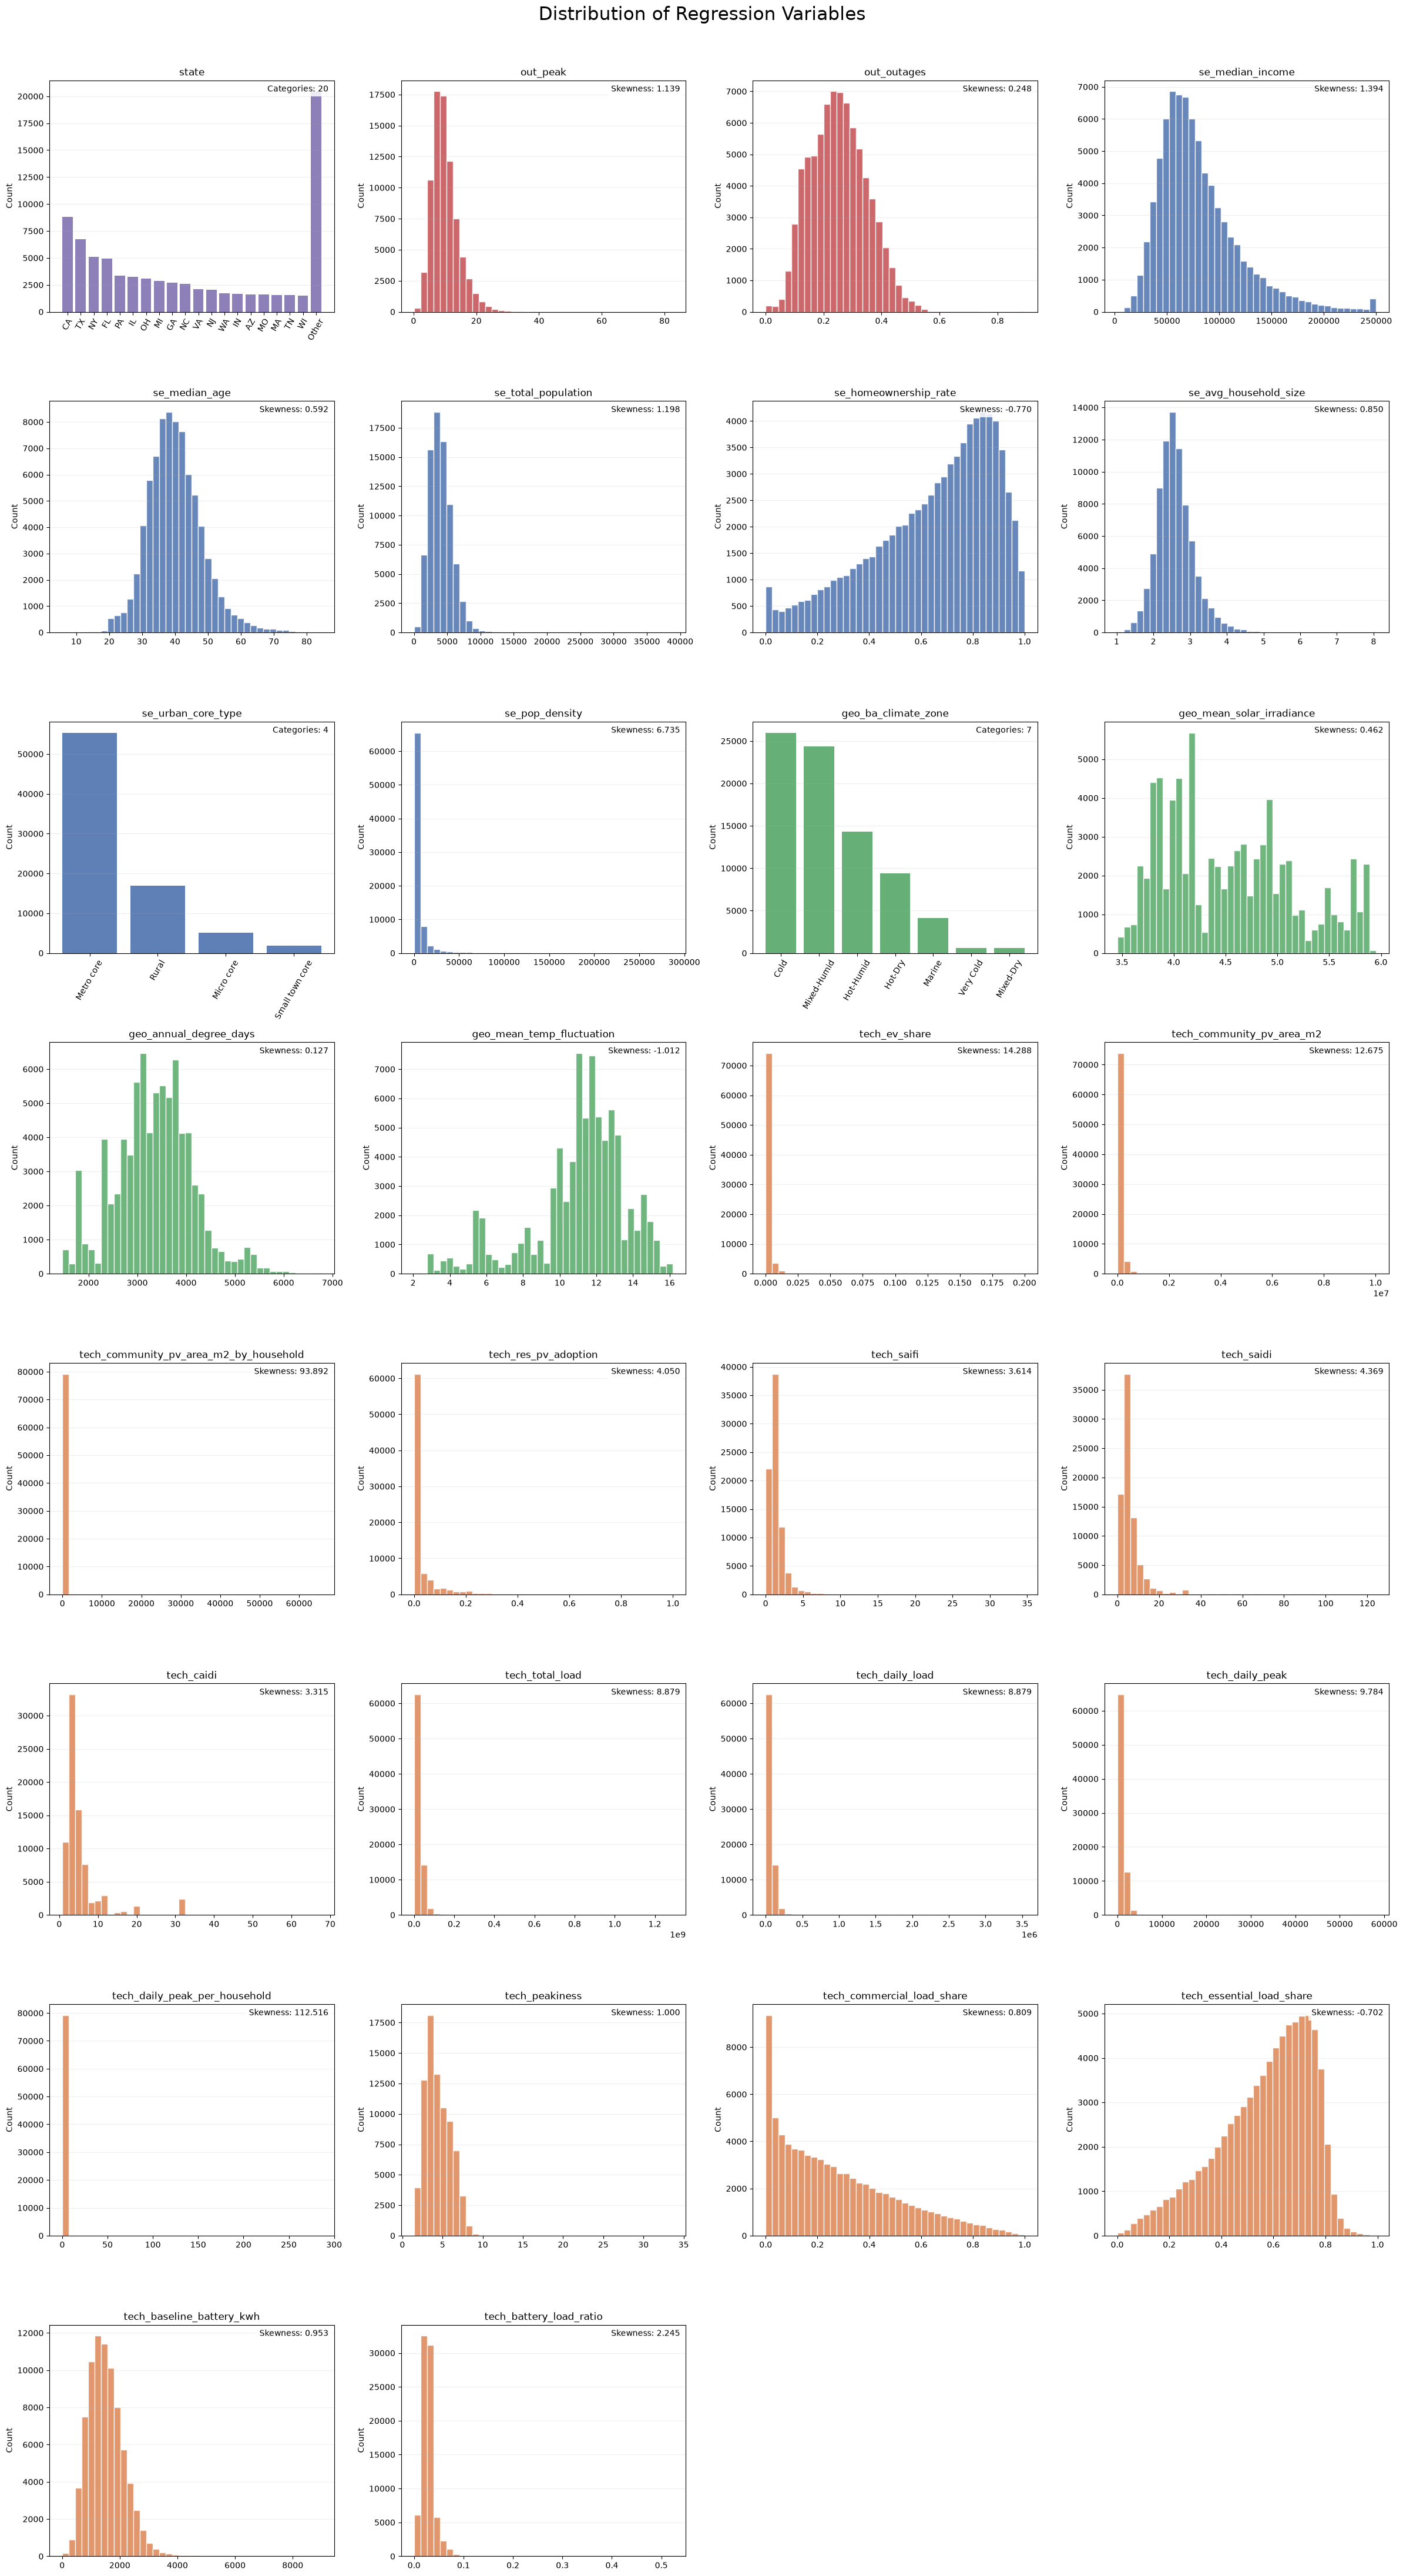

In [ ]:
analysis_columns = [col for col in final_df_clean.columns if col not in {"county_geoid", "tract_geoid"}]

category_colors = {
    "out": "#C44E52",
    "se": "#4C72B0",
    "tech": "#55A868",
    "geo": "#DD8452",
    "state": "#8172B2",
}

categorical_columns = ["state", "se_urban_core_type", "geo_ba_climate_zone"]
numeric_columns = [col for col in analysis_columns if col not in categorical_columns]

def variable_group(column_name):
    if column_name == "state":
        return "state"
    return column_name.split("_", 1)[0]

def variable_color(column_name):
    return category_colors.get(variable_group(column_name), "#666666")

plot_columns = analysis_columns
n_cols = 4
n_rows = int(np.ceil(len(plot_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 5.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, column in zip(axes, plot_columns):
    color = variable_color(column)
    if column in categorical_columns:
        counts = final_df_clean[column].fillna("Missing").astype(str).value_counts(dropna=False)
        if len(counts) > 20:
            top_counts = counts.iloc[:19]
            other_count = counts.iloc[19:].sum()
            counts = pd.concat([top_counts, pd.Series({"Other": other_count})])
        ax.bar(counts.index, counts.values, color=color, alpha=0.9)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=60)
        ax.text(
            0.98,
            0.98,
            f"Categories: {len(counts)}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
        )
    else:
        series = pd.to_numeric(final_df_clean[column], errors="coerce").dropna()
        ax.hist(series, bins=40, color=color, alpha=0.85, edgecolor="white")
        ax.set_ylabel("Count")
        skewness = series.skew() if len(series) > 2 else np.nan
        skew_text = f"Skewness: {skewness:.3f}" if pd.notna(skewness) else "Skewness: n/a"
        ax.text(
            0.98,
            0.98,
            skew_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
        )
    ax.set_title(column)
    ax.grid(axis="y", alpha=0.2)

for ax in axes[len(plot_columns):]:
    ax.axis("off")

fig.suptitle("Distribution of Regression Variables", fontsize=22, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


## Correlations

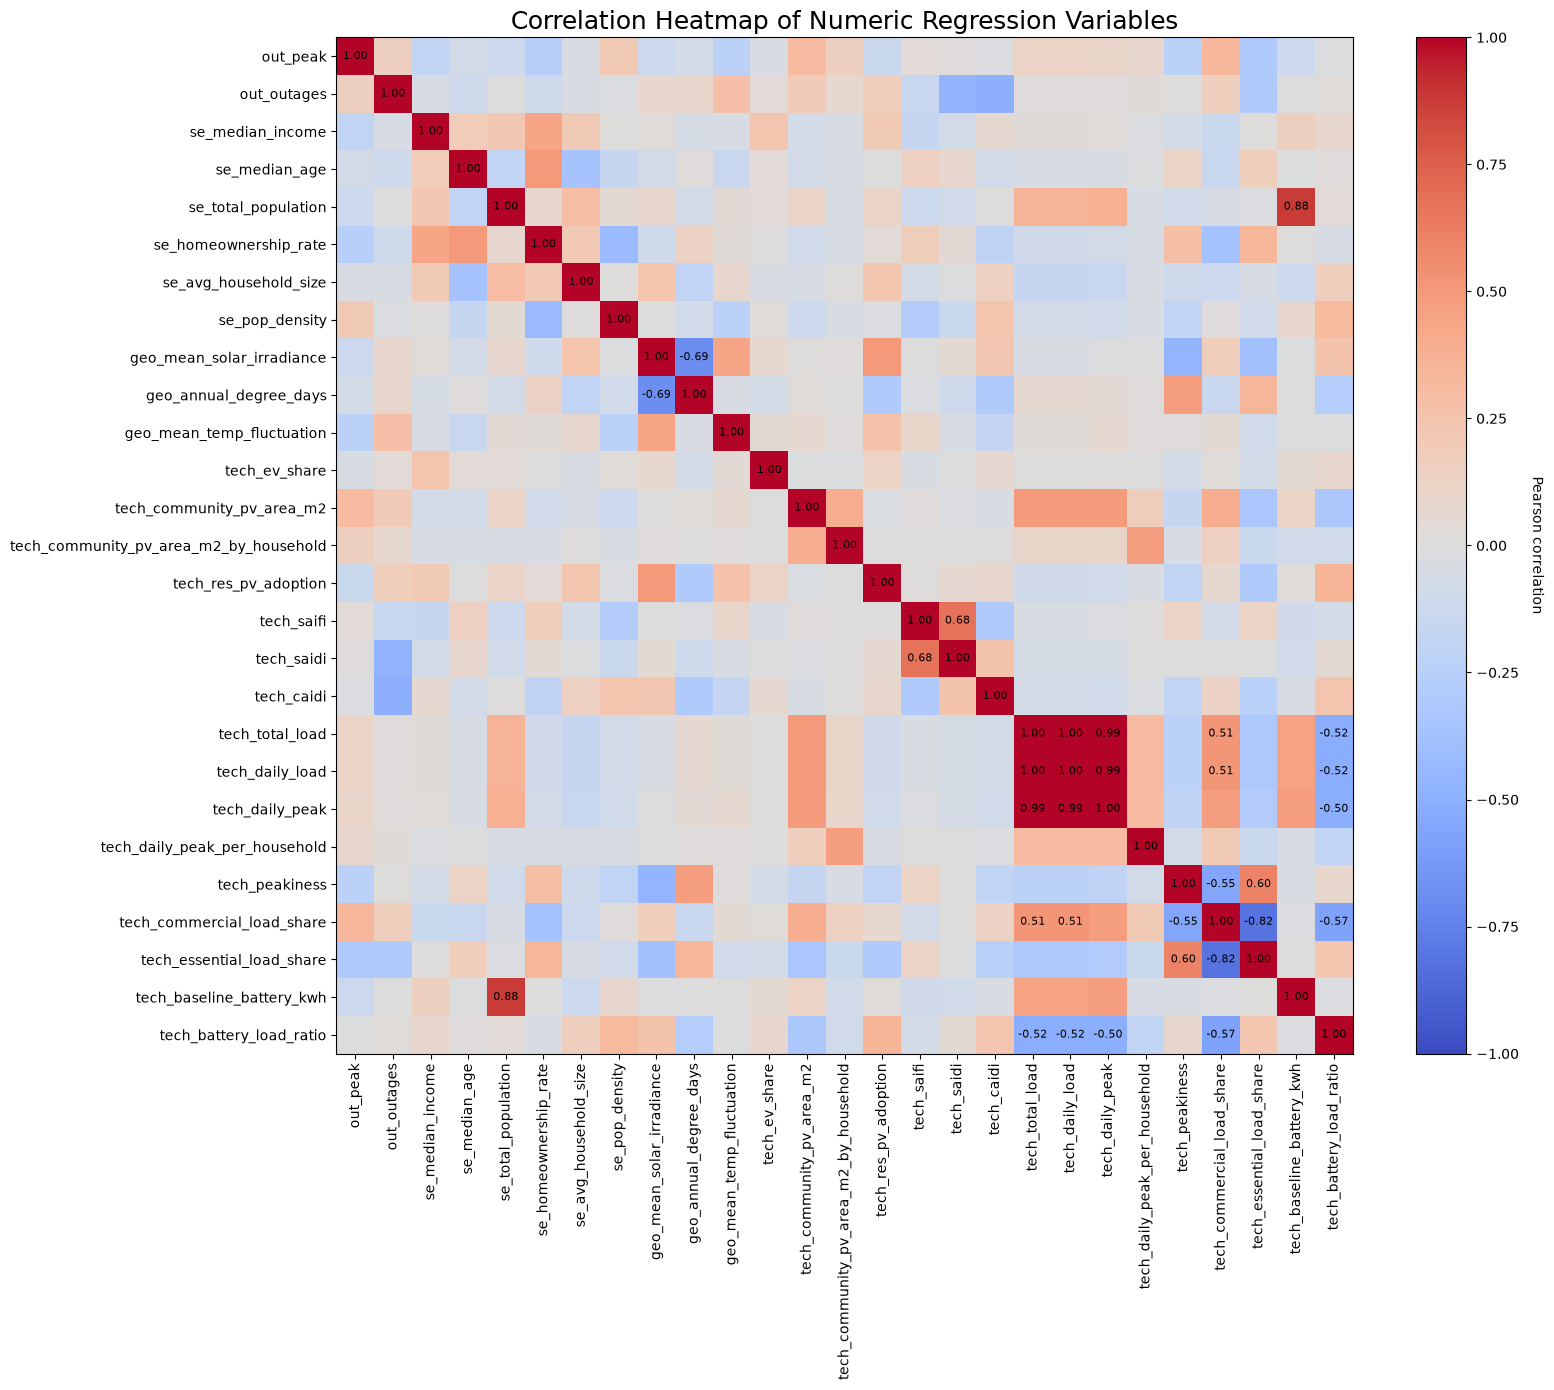

,out_peak,out_outages,se_median_income,se_median_age,se_total_population,se_homeownership_rate,se_avg_household_size,se_pop_density,geo_mean_solar_irradiance,geo_annual_degree_days,geo_mean_temp_fluctuation,tech_ev_share,tech_community_pv_area_m2,tech_community_pv_area_m2_by_household,tech_res_pv_adoption,tech_saifi,tech_saidi,tech_caidi,tech_total_load,tech_daily_load,tech_daily_peak,tech_daily_peak_per_household,tech_peakiness,tech_commercial_load_share,tech_essential_load_share,tech_baseline_battery_kwh,tech_battery_load_ratio
out_peak,1.000000,0.150414,-0.191289,-0.074388,-0.111707,-0.255278,-0.038202,0.199122,-0.121029,-0.062509,-0.224133,-0.043964,0.309767,0.149602,-0.132691,0.033239,0.011724,-0.021849,0.119512,0.119512,0.107648,0.080090,-0.231708,0.328330,-0.297491,-0.123862,-0.013693
out_outages,0.150414,1.000000,-0.050952,-0.104768,-0.002585,-0.108499,-0.036614,-0.021472,0.080821,0.088449,0.276717,0.033347,0.192435,0.071267,0.169636,-0.147518,-0.466058,-0.496019,0.011019,0.011019,0.010172,0.026271,0.001688,0.163195,-0.302872,-0.001964,0.019996
se_median_income,-0.191289,-0.050952,1.000000,0.186479,0.222000,0.430043,0.197947,0.001103,0.022968,-0.059210,-0.049939,0.239796,-0.066702,-0.034243,0.197581,-0.151910,-0.072995,0.061523,0.027686,0.027686,0.020379,-0.018819,-0.065487,-0.131393,0.004755,0.155066,0.084255
se_median_age,-0.074388,-0.104768,0.186479,1.000000,-0.183023,0.493812,-0.358730,-0.162520,-0.075268,0.009679,-0.136421,0.033901,-0.075163,-0.040736,-0.001319,0.144770,0.078686,-0.074620,-0.050785,-0.050785,-0.044190,-0.010416,0.117910,-0.135120,0.170337,-0.008596,0.012484
se_total_population,-0.111707,-0.002585,0.222000,-0.183023,1.000000,0.085444,0.295806,0.050549,0.084459,-0.074770,0.039511,0.033583,0.114805,-0.052832,0.113240,-0.109660,-0.085617,0.001596,0.353692,0.353692,0.380981,-0.049418,-0.086168,-0.054153,-0.022321,0.876123,0.032960
se_homeownership_rate,-0.255278,-0.108499,0.430043,0.493812,0.085444,1.000000,0.210613,-0.419344,-0.102641,0.132359,0.030865,-0.002394,-0.093599,-0.052297,0.035097,0.178450,0.045820,-0.199707,-0.094443,-0.094443,-0.070648,-0.041715,0.287021,-0.360555,0.336695,0.000504,-0.051385
se_avg_household_size,-0.038202,-0.036614,0.197947,-0.358730,0.295806,0.210613,1.000000,0.004165,0.248668,-0.190007,0.083854,-0.032342,-0.048669,0.002343,0.230614,-0.069670,-0.008633,0.140916,-0.152697,-0.152697,-0.142746,-0.037804,-0.109155,-0.120668,-0.052014,-0.111036,0.162585
se_pop_density,0.199122,-0.021472,0.001103,-0.162520,0.050549,-0.419344,0.004165,1.000000,-0.011774,-0.085481,-0.231338,0.018236,-0.115359,-0.039066,-0.023394,-0.276596,-0.130848,0.240483,-0.074831,-0.074831,-0.090360,-0.038358,-0.184400,0.013031,-0.083834,0.080384,0.315341
geo_mean_solar_irradiance,-0.121029,0.080821,0.022968,-0.075268,0.084459,-0.102641,0.248668,-0.011774,1.000000,-0.687362,0.443894,0.074716,0.000951,0.014637,0.494684,-0.000833,0.052759,0.221891,-0.041628,-0.041628,-0.014496,-0.000346,-0.459296,0.168539,-0.382654,-0.014886,0.252073
geo_annual_degree_days,-0.062509,0.088449,-0.059210,0.009679,-0.074770,0.132359,-0.190007,-0.085481,-0.687362,1.000000,-0.032758,-0.069163,0.021083,-0.004325,-0.301708,-0.021288,-0.103132,-0.293410,0.057454,0.057454,0.046284,0.012748,0.472522,-0.137589,0.338858,-0.001682,-0.271595


In [29]:
correlation_columns = [
    col for col in final_df_clean.columns
    if col not in {"county_geoid", "tract_geoid", "state", "se_urban_core_type", "geo_ba_climate_zone"}
]
correlation_df = final_df_clean[correlation_columns].apply(pd.to_numeric, errors="coerce")
correlation_matrix = correlation_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(18, 14))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(correlation_columns)))
ax.set_yticks(np.arange(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=90)
ax.set_yticklabels(correlation_columns)
ax.set_title("Correlation Heatmap of Numeric Regression Variables", fontsize=18)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        value = correlation_matrix.iloc[i, j]
        if pd.notna(value) and abs(value) >= 0.5:
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation", rotation=270, labelpad=18)
fig.tight_layout()
plt.show()

correlation_matrix


## Reduced Correlations

Zweiter bereinigter Datensatz nach Entfernung hoch korrelierter Variablen. Entfernt werden `tech_total_load`, `tech_daily_peak` und `se_total_population`. Die normalisierte Variable `tech_daily_peak_per_household` bleibt erhalten.

Rows in final_df_clean_reduced: 79,345
Removed columns: ['tech_total_load', 'tech_daily_peak', 'se_total_population']


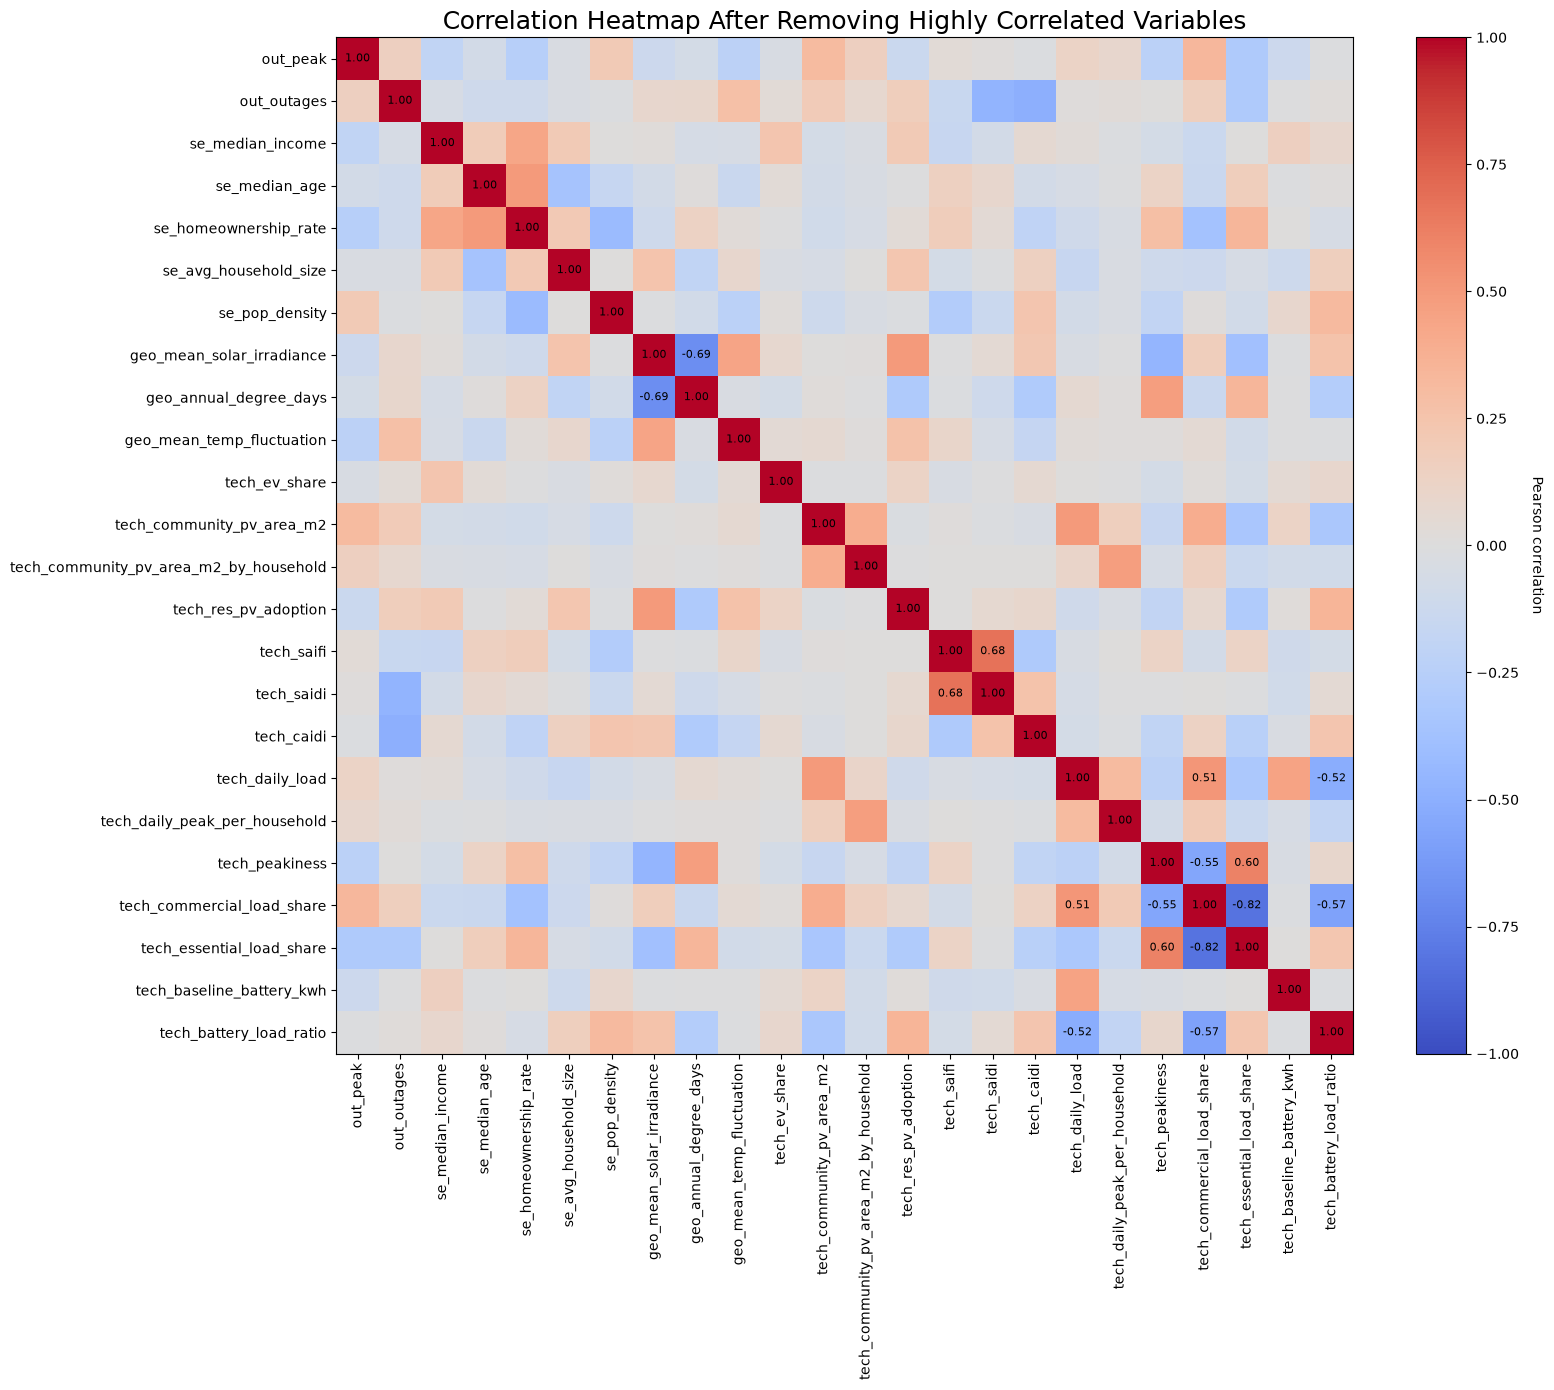

,out_peak,out_outages,se_median_income,se_median_age,se_homeownership_rate,se_avg_household_size,se_pop_density,geo_mean_solar_irradiance,geo_annual_degree_days,geo_mean_temp_fluctuation,tech_ev_share,tech_community_pv_area_m2,tech_community_pv_area_m2_by_household,tech_res_pv_adoption,tech_saifi,tech_saidi,tech_caidi,tech_daily_load,tech_daily_peak_per_household,tech_peakiness,tech_commercial_load_share,tech_essential_load_share,tech_baseline_battery_kwh,tech_battery_load_ratio
out_peak,1.000000,0.150414,-0.191289,-0.074388,-0.255278,-0.038202,0.199122,-0.121029,-0.062509,-0.224133,-0.043964,0.309767,0.149602,-0.132691,0.033239,0.011724,-0.021849,0.119512,0.080090,-0.231708,0.328330,-0.297491,-0.123862,-0.013693
out_outages,0.150414,1.000000,-0.050952,-0.104768,-0.108499,-0.036614,-0.021472,0.080821,0.088449,0.276717,0.033347,0.192435,0.071267,0.169636,-0.147518,-0.466058,-0.496019,0.011019,0.026271,0.001688,0.163195,-0.302872,-0.001964,0.019996
se_median_income,-0.191289,-0.050952,1.000000,0.186479,0.430043,0.197947,0.001103,0.022968,-0.059210,-0.049939,0.239796,-0.066702,-0.034243,0.197581,-0.151910,-0.072995,0.061523,0.027686,-0.018819,-0.065487,-0.131393,0.004755,0.155066,0.084255
se_median_age,-0.074388,-0.104768,0.186479,1.000000,0.493812,-0.358730,-0.162520,-0.075268,0.009679,-0.136421,0.033901,-0.075163,-0.040736,-0.001319,0.144770,0.078686,-0.074620,-0.050785,-0.010416,0.117910,-0.135120,0.170337,-0.008596,0.012484
se_homeownership_rate,-0.255278,-0.108499,0.430043,0.493812,1.000000,0.210613,-0.419344,-0.102641,0.132359,0.030865,-0.002394,-0.093599,-0.052297,0.035097,0.178450,0.045820,-0.199707,-0.094443,-0.041715,0.287021,-0.360555,0.336695,0.000504,-0.051385
se_avg_household_size,-0.038202,-0.036614,0.197947,-0.358730,0.210613,1.000000,0.004165,0.248668,-0.190007,0.083854,-0.032342,-0.048669,0.002343,0.230614,-0.069670,-0.008633,0.140916,-0.152697,-0.037804,-0.109155,-0.120668,-0.052014,-0.111036,0.162585
se_pop_density,0.199122,-0.021472,0.001103,-0.162520,-0.419344,0.004165,1.000000,-0.011774,-0.085481,-0.231338,0.018236,-0.115359,-0.039066,-0.023394,-0.276596,-0.130848,0.240483,-0.074831,-0.038358,-0.184400,0.013031,-0.083834,0.080384,0.315341
geo_mean_solar_irradiance,-0.121029,0.080821,0.022968,-0.075268,-0.102641,0.248668,-0.011774,1.000000,-0.687362,0.443894,0.074716,0.000951,0.014637,0.494684,-0.000833,0.052759,0.221891,-0.041628,-0.000346,-0.459296,0.168539,-0.382654,-0.014886,0.252073
geo_annual_degree_days,-0.062509,0.088449,-0.059210,0.009679,0.132359,-0.190007,-0.085481,-0.687362,1.000000,-0.032758,-0.069163,0.021083,-0.004325,-0.301708,-0.021288,-0.103132,-0.293410,0.057454,0.012748,0.472522,-0.137589,0.338858,-0.001682,-0.271595
geo_mean_temp_fluctuation,-0.224133,0.276717,-0.049939,-0.136421,0.030865,0.083854,-0.231338,0.443894,-0.032758,1.000000,0.042897,0.056325,0.010978,0.258724,0.099944,-0.048110,-0.169948,0.027482,0.012149,0.011677,0.054476,-0.085386,-0.004140,-0.011022


In [ ]:
columns_to_remove_high_corr = ["tech_total_load", "tech_daily_peak", "se_total_population"]
final_df_clean_reduced = final_df_clean.drop(columns=columns_to_remove_high_corr).copy()

print(f"Rows in final_df_clean_reduced: {len(final_df_clean_reduced):,}")
print("Removed columns:", columns_to_remove_high_corr)

reduced_correlation_columns = [
    col for col in final_df_clean_reduced.columns
    if col not in {"county_geoid", "tract_geoid", "state", "se_urban_core_type", "geo_ba_climate_zone"}
]
reduced_correlation_df = final_df_clean_reduced[reduced_correlation_columns].apply(pd.to_numeric, errors="coerce")
reduced_correlation_matrix = reduced_correlation_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(18, 14))
im = ax.imshow(reduced_correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(reduced_correlation_columns)))
ax.set_yticks(np.arange(len(reduced_correlation_columns)))
ax.set_xticklabels(reduced_correlation_columns, rotation=90)
ax.set_yticklabels(reduced_correlation_columns)
ax.set_title("Correlation Heatmap After Removing Highly Correlated Variables", fontsize=18)

for i in range(len(reduced_correlation_columns)):
    for j in range(len(reduced_correlation_columns)):
        value = reduced_correlation_matrix.iloc[i, j]
        if pd.notna(value) and abs(value) >= 0.5:
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation", rotation=270, labelpad=18)
fig.tight_layout()
plt.show()

reduced_correlation_matrix


# C: Regressions


In [63]:
regression_df = final_df_clean_reduced.copy()

SOCIO_COLUMNS = [
    "se_median_income",
    "se_median_age",
    "se_homeownership_rate",
    "se_avg_household_size",
    "se_pop_density",
    "se_urban_core_type",
]

GEO_COLUMNS = [
    "geo_ba_climate_zone",
    "geo_mean_solar_irradiance",
    "geo_annual_degree_days",
    "geo_mean_temp_fluctuation",
]

TECH_COLUMNS = [
    "tech_ev_share",
    "tech_community_pv_area_m2",
    "tech_community_pv_area_m2_by_household",
    "tech_res_pv_adoption",
    "tech_saifi",
    "tech_saidi",
    "tech_caidi",
    "tech_daily_load",
    "tech_daily_peak_per_household",
    "tech_peakiness",
    "tech_commercial_load_share",
    "tech_essential_load_share",
    "tech_baseline_battery_kwh",
    "tech_battery_load_ratio",
]

OUTCOMES = ["out_peak", "out_outages"]

CATEGORY_COLORS = {
    "Socio": "#2a6f97",
    "Geo": "#c97b36",
    "Tech": "#3a7d44",
    "Other": "#6c757d",
}

def significance_stars(p_value):
    if pd.isna(p_value):
        return ""
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""

def format_coef_with_stars(coef, p_value, decimals=4):
    if pd.isna(coef):
        return ""
    return f"{coef:.{decimals}f}{significance_stars(p_value)}"

def prepare_design_matrix(df, feature_columns):
    X = df[feature_columns].copy()
    categorical = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    if categorical:
        X = pd.get_dummies(X, columns=categorical, drop_first=True, dtype=float)
    X = X.apply(pd.to_numeric, errors="coerce").astype(float)
    X.insert(0, "const", 1.0)
    return X

def cluster_robust_covariance(X_mat, resid, clusters):
    xtx_inv = np.linalg.pinv(X_mat.T @ X_mat)
    cluster_codes = pd.Series(clusters).astype(str).to_numpy()
    unique_clusters = pd.unique(cluster_codes)
    meat = np.zeros((X_mat.shape[1], X_mat.shape[1]))

    for cluster in unique_clusters:
        mask = cluster_codes == cluster
        X_g = X_mat[mask]
        u_g = resid[mask][:, None]
        score_g = X_g.T @ u_g
        meat += score_g @ score_g.T

    n_obs, n_params = X_mat.shape
    n_clusters = len(unique_clusters)
    correction = 1.0
    if n_clusters > 1 and n_obs > n_params:
        correction = (n_clusters / (n_clusters - 1)) * ((n_obs - 1) / (n_obs - n_params))

    cov_beta = correction * xtx_inv @ meat @ xtx_inv
    return cov_beta, n_clusters

def compute_vif_table(X):
    X_no_const = X.drop(columns=["const"], errors="ignore")
    rows = []

    for column in X_no_const.columns:
        y = X_no_const[column].to_numpy(dtype=float)
        other_columns = X_no_const.drop(columns=[column])

        if other_columns.shape[1] == 0:
            vif = np.nan
        else:
            Z = other_columns.to_numpy(dtype=float)
            Z = np.column_stack([np.ones(len(Z)), Z])
            beta_aux, _, _, _ = np.linalg.lstsq(Z, y, rcond=None)
            fitted_aux = Z @ beta_aux
            sst_aux = float(np.sum((y - y.mean()) ** 2))
            sse_aux = float(np.sum((y - fitted_aux) ** 2))
            if sst_aux <= 0:
                vif = np.nan
            else:
                r2_aux = 1.0 - sse_aux / sst_aux
                vif = np.inf if r2_aux >= 0.999999 else 1.0 / (1.0 - r2_aux)

        rows.append({"term": column, "vif": vif})

    return pd.DataFrame(rows).sort_values("vif", ascending=False).reset_index(drop=True)

def infer_term_group(term):
    if term.startswith("se_"):
        return "Socio"
    if term.startswith("geo_"):
        return "Geo"
    if term.startswith("tech_"):
        return "Tech"
    return "Other"

def compute_effect_sizes(X, coef_table):
    effect_rows = []
    for term in X.columns:
        if term == "const":
            continue

        series = X[term]
        spread = float(series.quantile(0.75) - series.quantile(0.25))
        unique_values = set(series.dropna().unique().tolist())
        if spread == 0.0 and unique_values.issubset({0.0, 1.0}):
            spread = 1.0

        coef = float(coef_table.loc[term, "coef"])
        p_value = float(coef_table.loc[term, "p_value"])
        stars = significance_stars(p_value)
        effect_size = coef * spread if np.isfinite(spread) else np.nan
        effect_rows.append({
            "term": term,
            "term_with_stars": f"{term}{stars}",
            "group": infer_term_group(term),
            "p_value": p_value,
            "stars": stars,
            "iqr_or_discrete_change": spread,
            "effect_size": effect_size,
            "abs_effect_size": abs(effect_size) if np.isfinite(effect_size) else np.nan,
        })

    effect_df = pd.DataFrame(effect_rows)
    return effect_df.sort_values("abs_effect_size", ascending=False).reset_index(drop=True)

def plot_effect_sizes(effect_df, model_name, outcome, max_terms=20):
    plot_df = effect_df.dropna(subset=["effect_size"]).copy()
    plot_df = plot_df[plot_df["abs_effect_size"] > 0]
    plot_df = plot_df.head(max_terms).iloc[::-1]

    if plot_df.empty:
        print("No finite effect sizes available for plotting.")
        return

    colors = plot_df["group"].map(CATEGORY_COLORS).fillna(CATEGORY_COLORS["Other"])
    labels = plot_df["term_with_stars"]
    fig, ax = plt.subplots(figsize=(11, max(6, 0.42 * len(plot_df))))
    bars = ax.barh(labels, plot_df["effect_size"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{model_name} | {outcome} | IQR-scaled effect sizes")
    ax.set_xlabel("Coefficient x (75th percentile - 25th percentile)")
    ax.set_ylabel("")

    max_abs = float(plot_df["abs_effect_size"].max())
    text_offset = max_abs * 0.02 if max_abs > 0 else 0.02
    for bar, effect_size, stars in zip(bars, plot_df["effect_size"], plot_df["stars"]):
        x = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ha = "left" if x >= 0 else "right"
        x_text = x + text_offset if x >= 0 else x - text_offset
        ax.text(x_text, y, f"{effect_size:.2f}{stars}", va="center", ha=ha, fontsize=9)

    ax.text(
        0.99,
        0.01,
        "*** p<0.01, ** p<0.05, * p<0.10",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        color="#444444",
    )

    plt.tight_layout()
    plt.show()

def ols_summary(df, outcome, feature_columns, model_name, cluster_column="county_geoid"):
    model_df = df[[outcome] + feature_columns + [cluster_column]].dropna().copy()
    y = model_df[outcome].astype(float).to_numpy()
    X = prepare_design_matrix(model_df, feature_columns)
    X_mat = X.to_numpy(dtype=float)
    clusters = model_df[cluster_column].astype(str).to_numpy()
    n_obs, n_params = X_mat.shape

    beta, _, _, _ = np.linalg.lstsq(X_mat, y, rcond=None)
    fitted = X_mat @ beta
    resid = y - fitted

    sse = float(np.sum(resid ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    ssr = float(np.sum((fitted - y.mean()) ** 2))
    r2 = 1.0 - sse / sst if sst > 0 else np.nan
    adj_r2 = 1.0 - (1.0 - r2) * (n_obs - 1) / (n_obs - n_params) if n_obs > n_params else np.nan
    mse_resid = sse / (n_obs - n_params)

    cov_beta, n_clusters = cluster_robust_covariance(X_mat, resid, clusters)
    std_err = np.sqrt(np.clip(np.diag(cov_beta), a_min=0.0, a_max=None))
    cluster_df = max(n_clusters - 1, 1)
    t_stats = np.divide(beta, std_err, out=np.full_like(beta, np.nan), where=std_err > 0)
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=cluster_df))

    if n_params > 1 and n_obs > n_params:
        f_stat = (ssr / (n_params - 1)) / mse_resid
        f_p_value = 1 - stats.f.cdf(f_stat, n_params - 1, n_obs - n_params)
    else:
        f_stat = np.nan
        f_p_value = np.nan

    coef_table = pd.DataFrame({
        "coef": beta,
        "clustered_std_err": std_err,
        "t_clustered": t_stats,
        "p_value": p_values,
    }, index=X.columns)
    coef_table["stars"] = coef_table["p_value"].apply(significance_stars)
    coef_table["coef_with_stars"] = coef_table.apply(
        lambda row: format_coef_with_stars(row["coef"], row["p_value"]),
        axis=1,
    )

    vif_table = compute_vif_table(X)
    effect_table = compute_effect_sizes(X, coef_table)

    model_stats = pd.Series({
        "model": model_name,
        "outcome": outcome,
        "n_obs": n_obs,
        "n_params": n_params,
        "n_county_clusters": n_clusters,
        "r2": r2,
        "adj_r2": adj_r2,
        "rmse": np.sqrt(mse_resid),
        "f_stat": f_stat,
        "f_p_value": f_p_value,
    })
    return model_stats, coef_table, vif_table, effect_table

def run_model_block(df, feature_columns, model_name):
    results = {}
    for outcome in OUTCOMES:
        stats_table, coef_table, vif_table, effect_table = ols_summary(df, outcome, feature_columns, model_name)
        print(f"\n=== {model_name} | {outcome} ===")
        print(stats_table.to_string())
        print("\nCoefficients with county-clustered standard errors:")
        print(coef_table.round(4).to_string())
        print("\nVIF:")
        print(vif_table.round(2).to_string(index=False))
        plot_effect_sizes(effect_table, model_name, outcome)
        results[outcome] = {
            "stats": stats_table,
            "coefs": coef_table,
            "vif": vif_table,
            "effects": effect_table,
        }
    return results


## Socio-Economomics



=== Socioeconomics | out_peak ===
model                Socioeconomics
outcome                    out_peak
n_obs                         79345
n_params                          9
n_county_clusters              2858
r2                         0.099237
adj_r2                     0.099147
rmse                       4.022968
f_stat                  1092.560159
f_p_value                       0.0

Coefficients with county-clustered standard errors:
                                      coef  clustered_std_err  t_clustered  p_value stars coef_with_stars
const                               9.8182             0.7756      12.6594   0.0000   ***       9.8182***
se_median_income                   -0.0000             0.0000      -3.9612   0.0001   ***      -0.0000***
se_median_age                       0.0470             0.0156       3.0189   0.0026   ***       0.0470***
se_homeownership_rate              -4.3057             0.8798      -4.8940   0.0000   ***      -4.3057***
se_avg_household_size 

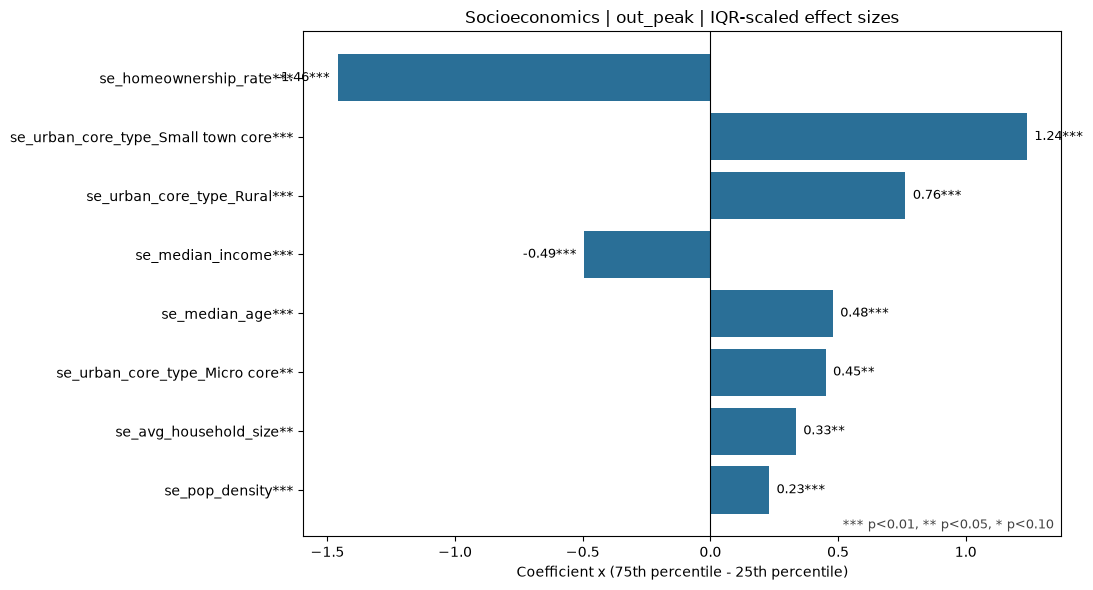


=== Socioeconomics | out_outages ===
model                Socioeconomics
outcome                 out_outages
n_obs                         79345
n_params                          9
n_county_clusters              2858
r2                         0.027975
adj_r2                     0.027877
rmse                       0.095003
f_stat                   285.408397
f_p_value                       0.0

Coefficients with county-clustered standard errors:
                                      coef  clustered_std_err  t_clustered  p_value stars coef_with_stars
const                               0.3449             0.0369       9.3568   0.0000   ***       0.3449***
se_median_income                    0.0000             0.0000       1.0509   0.2934                0.0000
se_median_age                      -0.0012             0.0006      -1.8851   0.0595     *        -0.0012*
se_homeownership_rate              -0.0473             0.0343      -1.3766   0.1688               -0.0473
se_avg_household_si

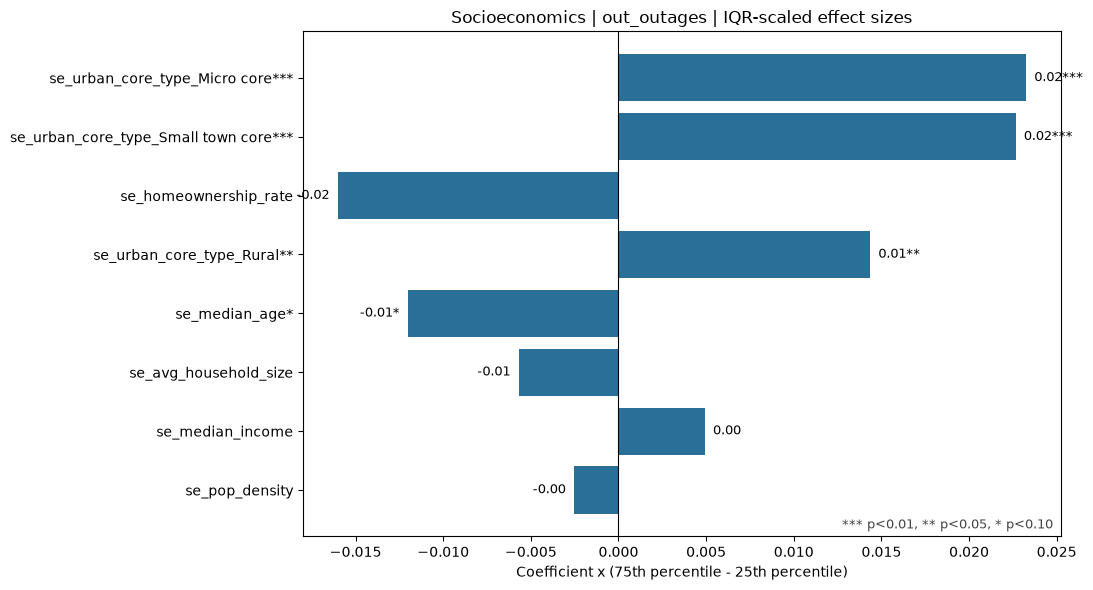

In [64]:
socio_results = run_model_block(regression_df, SOCIO_COLUMNS, "Socioeconomics")

## Geografic



=== Geographic | out_peak ===
model                 Geographic
outcome                 out_peak
n_obs                      79345
n_params                      10
n_county_clusters           2858
r2                      0.114856
adj_r2                  0.114755
rmse                    3.987964
f_stat               1143.826913
f_p_value                    0.0

Coefficients with county-clustered standard errors:
                                    coef  clustered_std_err  t_clustered  p_value stars coef_with_stars
const                            16.1048             1.8705       8.6100   0.0000   ***      16.1048***
geo_mean_solar_irradiance         0.5443             0.4110       1.3241   0.1856                0.5443
geo_annual_degree_days           -0.0013             0.0003      -4.8233   0.0000   ***      -0.0013***
geo_mean_temp_fluctuation        -0.2561             0.1050      -2.4396   0.0148    **       -0.2561**
geo_ba_climate_zone_Hot-Dry      -5.1305             0.6334      -

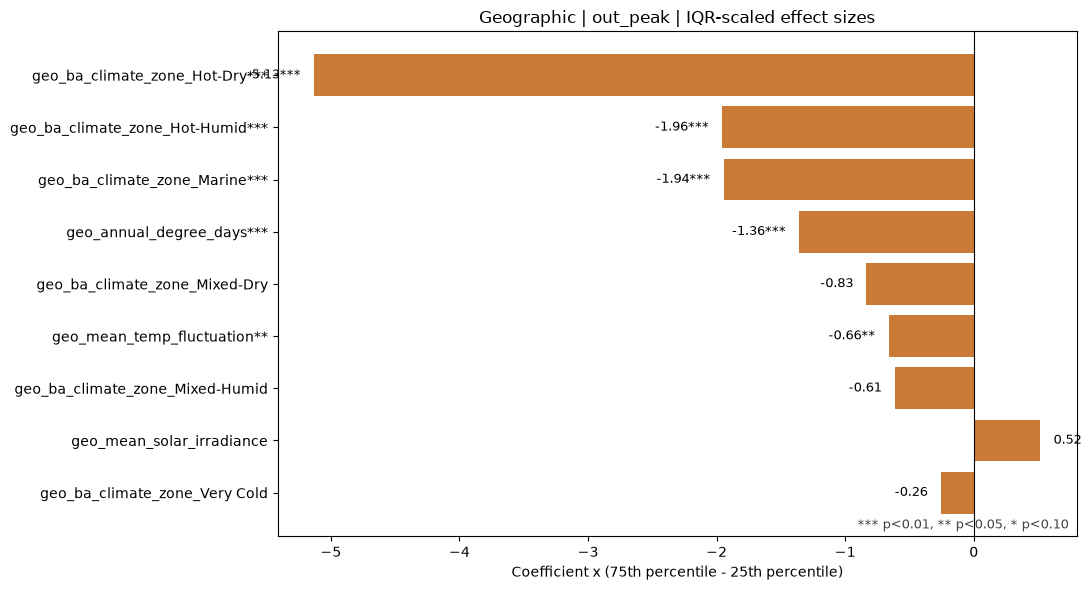


=== Geographic | out_outages ===
model                 Geographic
outcome              out_outages
n_obs                      79345
n_params                      10
n_county_clusters           2858
r2                      0.151934
adj_r2                  0.151837
rmse                    0.088739
f_stat               1579.234488
f_p_value                    0.0

Coefficients with county-clustered standard errors:
                                   coef  clustered_std_err  t_clustered  p_value stars coef_with_stars
const                           -0.0226             0.0933      -0.2422   0.8086               -0.0226
geo_mean_solar_irradiance        0.0498             0.0107       4.6567   0.0000   ***       0.0498***
geo_annual_degree_days           0.0000             0.0000       0.2036   0.8387                0.0000
geo_mean_temp_fluctuation        0.0074             0.0026       2.8804   0.0040   ***       0.0074***
geo_ba_climate_zone_Hot-Dry     -0.0907             0.0295      -3.0

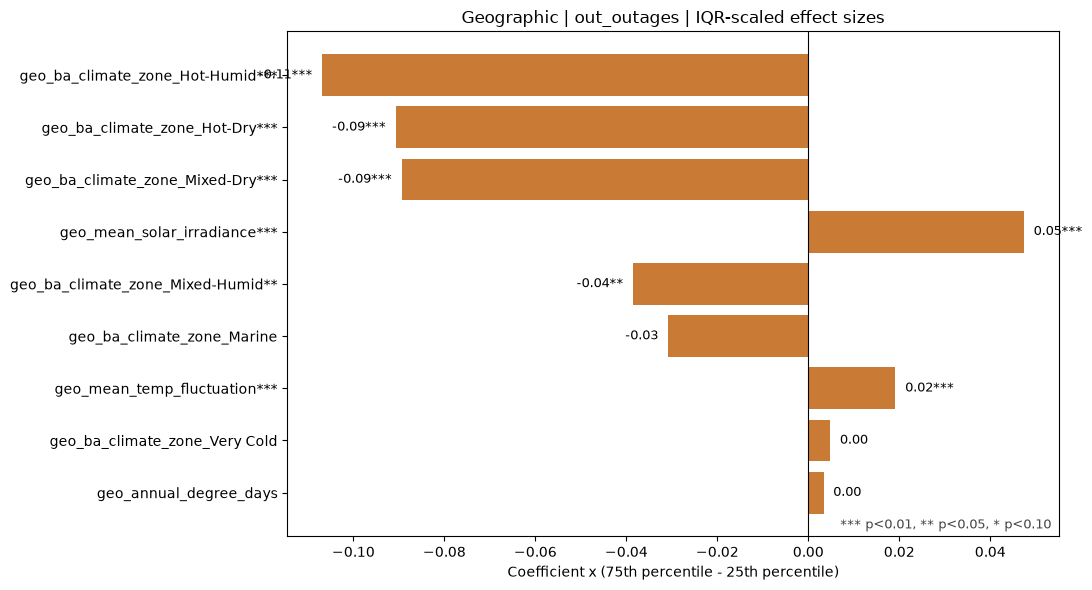

In [65]:
geo_results = run_model_block(regression_df, GEO_COLUMNS, "Geographic")


## Tech



=== Tech | out_peak ===
model                       Tech
outcome                 out_peak
n_obs                      79345
n_params                      15
n_county_clusters           2858
r2                       0.34769
adj_r2                  0.347575
rmse                    3.423614
f_stat               3020.286374
f_p_value                    0.0

Coefficients with county-clustered standard errors:
                                            coef  clustered_std_err  t_clustered  p_value stars coef_with_stars
const                                     3.4715             1.1133       3.1182   0.0018   ***       3.4715***
tech_ev_share                           -52.9221             0.3334    -158.7185   0.0000   ***     -52.9221***
tech_community_pv_area_m2                 0.0000             0.0000      10.5054   0.0000   ***       0.0000***
tech_community_pv_area_m2_by_household   -0.0001             0.0003      -0.4388   0.6608               -0.0001
tech_res_pv_adoption            

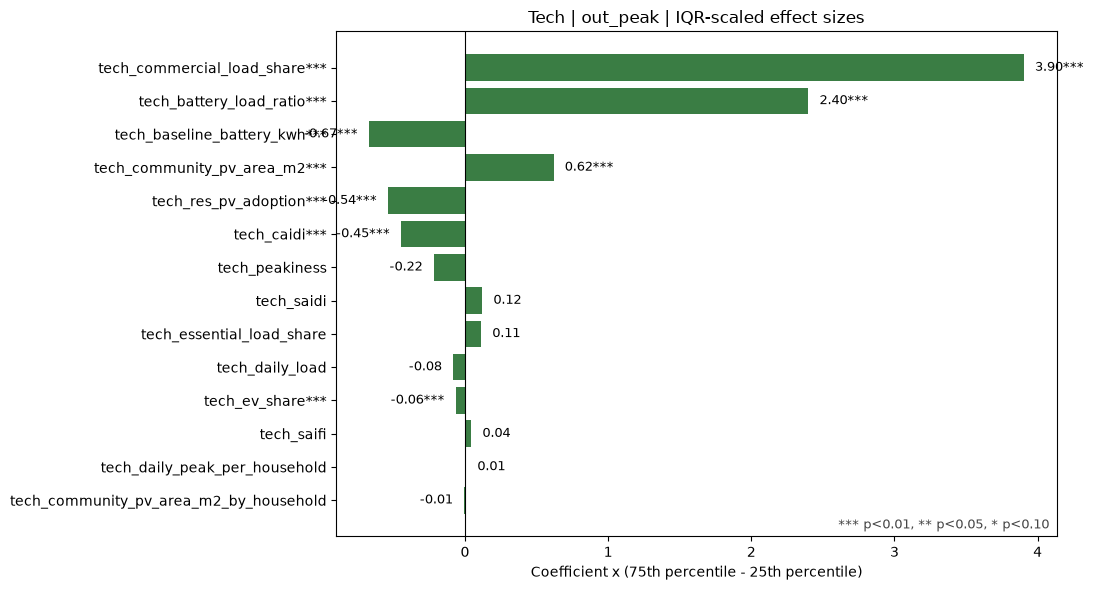


=== Tech | out_outages ===
model                        Tech
outcome               out_outages
n_obs                       79345
n_params                       15
n_county_clusters            2858
r2                       0.686268
adj_r2                   0.686212
rmse                     0.053975
f_stat               12394.921201
f_p_value                     0.0

Coefficients with county-clustered standard errors:
                                          coef  clustered_std_err  t_clustered  p_value stars coef_with_stars
const                                   0.3934             0.0181      21.7538   0.0000   ***       0.3934***
tech_ev_share                           0.5351             0.0057      93.1807   0.0000   ***       0.5351***
tech_community_pv_area_m2               0.0000             0.0000       8.6556   0.0000   ***       0.0000***
tech_community_pv_area_m2_by_household -0.0000             0.0000      -4.4808   0.0000   ***      -0.0000***
tech_res_pv_adoption         

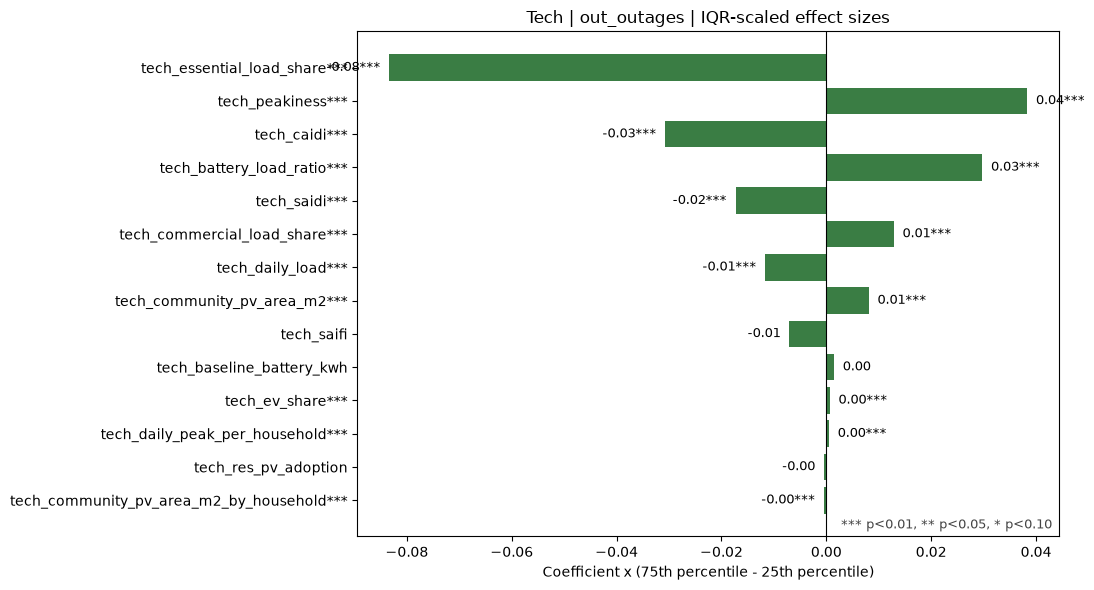

In [66]:
tech_results = run_model_block(regression_df, TECH_COLUMNS, "Tech")


## Kitchen Sink



=== Kitchen Sink | out_peak ===
model                Kitchen Sink
outcome                  out_peak
n_obs                       79345
n_params                       32
n_county_clusters            2858
r2                       0.511998
adj_r2                   0.511807
rmse                     2.961523
f_stat                2684.291108
f_p_value                     0.0

Coefficients with county-clustered standard errors:
                                            coef  clustered_std_err  t_clustered  p_value stars coef_with_stars
const                                     9.4477             2.3147       4.0816   0.0000   ***       9.4477***
se_median_income                         -0.0000             0.0000      -2.4286   0.0152    **       -0.0000**
se_median_age                             0.0112             0.0054       2.0665   0.0389    **        0.0112**
se_homeownership_rate                    -0.5986             0.2622      -2.2831   0.0225    **       -0.5986**
se_avg_househo

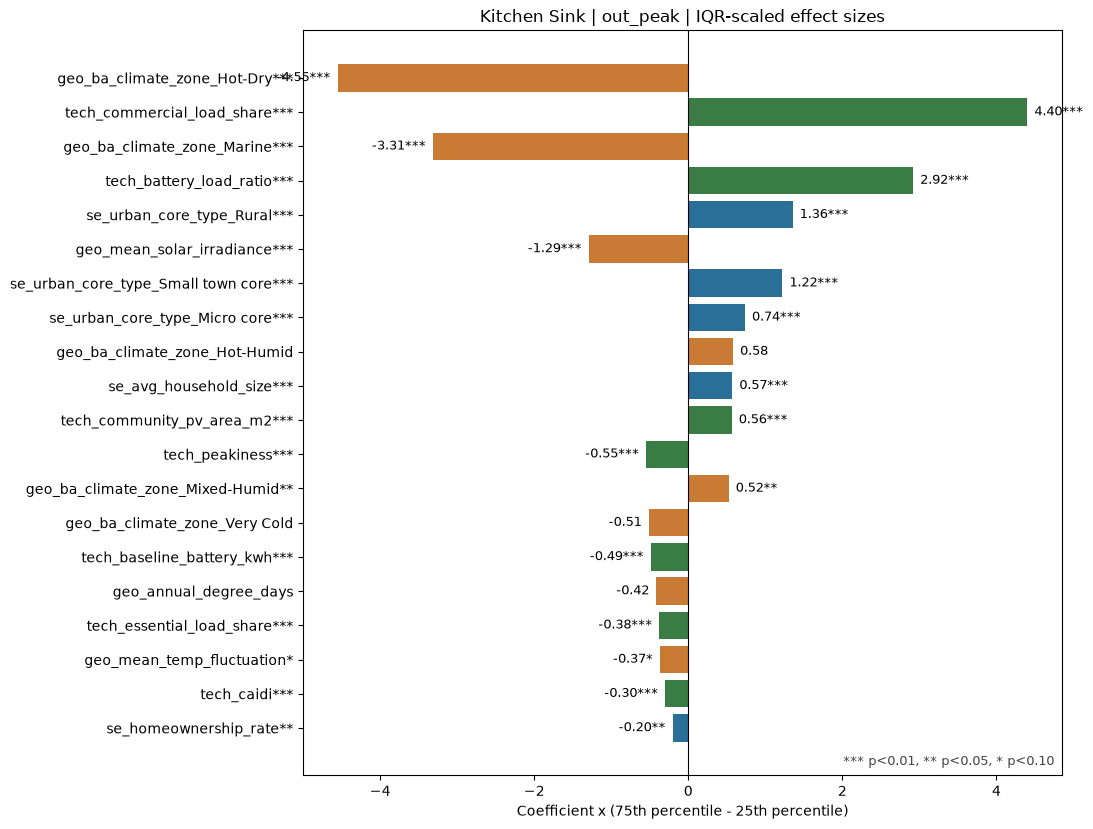


=== Kitchen Sink | out_outages ===
model                Kitchen Sink
outcome               out_outages
n_obs                       79345
n_params                       32
n_county_clusters            2858
r2                        0.73211
adj_r2                   0.732005
rmse                     0.049881
f_stat                 6992.01857
f_p_value                     0.0

Coefficients with county-clustered standard errors:
                                          coef  clustered_std_err  t_clustered  p_value stars coef_with_stars
const                                   0.4313             0.0373      11.5768   0.0000   ***       0.4313***
se_median_income                       -0.0000             0.0000      -0.4242   0.6715               -0.0000
se_median_age                          -0.0002             0.0001      -1.4711   0.1414               -0.0002
se_homeownership_rate                  -0.0257             0.0049      -5.3005   0.0000   ***      -0.0257***
se_avg_household_size

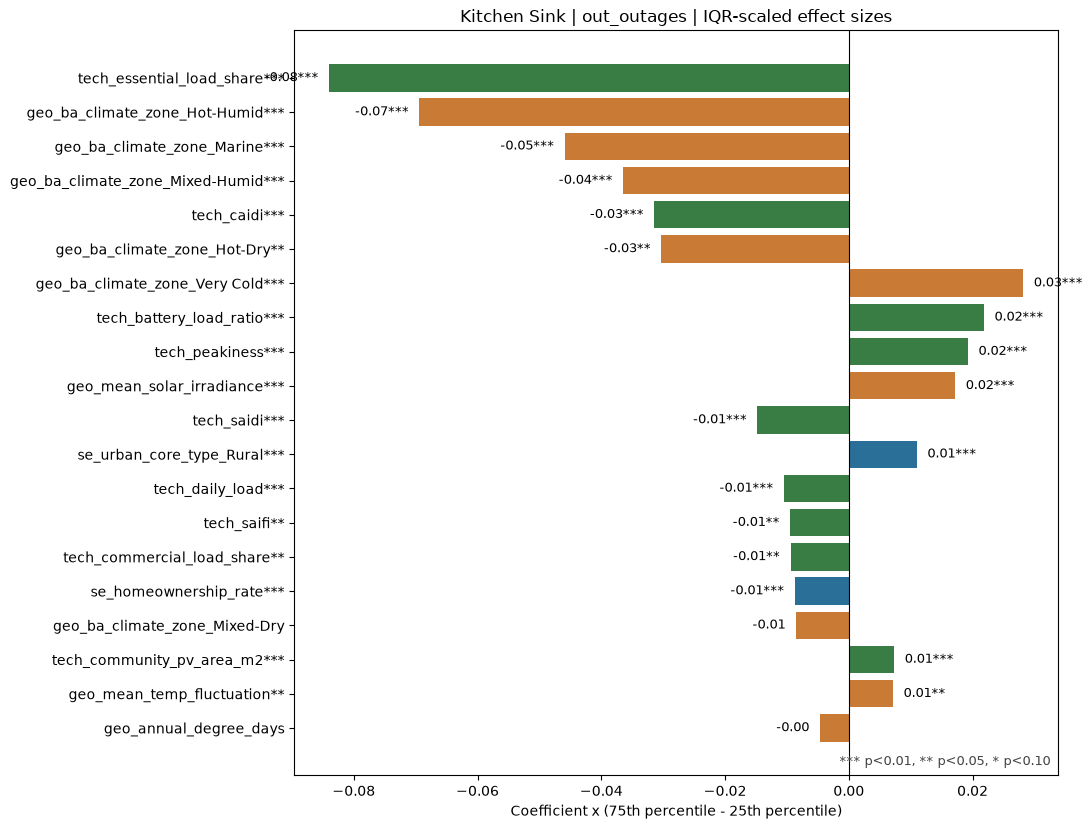

In [67]:
kitchen_sink_columns = SOCIO_COLUMNS + GEO_COLUMNS + TECH_COLUMNS
kitchen_sink_results = run_model_block(regression_df, kitchen_sink_columns, "Kitchen Sink")

## Compact Model Summary


In [68]:
ALL_MODEL_RESULTS = {
    "Socioeconomics": socio_results,
    "Geographic": geo_results,
    "Tech": tech_results,
    "Kitchen Sink": kitchen_sink_results,
}

def build_compact_regression_table(all_results):
    rows = []
    for model_name, outcome_dict in all_results.items():
        for outcome, result in outcome_dict.items():
            stats_row = result["stats"]
            coef_df = result["coefs"].drop(index="const", errors="ignore").reset_index()
            coef_df = coef_df.rename(columns={"index": "term"})
            coef_df["model"] = model_name
            coef_df["outcome"] = outcome
            coef_df["r2"] = stats_row["r2"]
            coef_df["adj_r2"] = stats_row["adj_r2"]
            coef_df["n_obs"] = stats_row["n_obs"]
            rows.append(
                coef_df[
                    ["model", "outcome", "term", "coef_with_stars", "p_value", "r2", "adj_r2", "n_obs"]
                ]
            )
    return pd.concat(rows, ignore_index=True)

compact_regression_table = build_compact_regression_table(ALL_MODEL_RESULTS)

for outcome in OUTCOMES:
    print(f"\n=== Compact Regression Table | {outcome} ===")
    compact_view = compact_regression_table[compact_regression_table["outcome"] == outcome].copy()
    print(compact_view.round({
        "p_value": 4,
        "r2": 4,
        "adj_r2": 4,
    }).to_string(index=False))

print("\nSignificance codes: *** p<0.01, ** p<0.05, * p<0.10")



=== Compact Regression Table | out_peak ===
         model  outcome                                   term coef_with_stars  p_value     r2  adj_r2  n_obs
Socioeconomics out_peak                       se_median_income      -0.0000***   0.0001 0.0992  0.0991  79345
Socioeconomics out_peak                          se_median_age       0.0470***   0.0026 0.0992  0.0991  79345
Socioeconomics out_peak                  se_homeownership_rate      -4.3057***   0.0000 0.0992  0.0991  79345
Socioeconomics out_peak                  se_avg_household_size        0.5769**   0.0247 0.0992  0.0991  79345
Socioeconomics out_peak                         se_pop_density       0.0000***   0.0009 0.0992  0.0991  79345
Socioeconomics out_peak          se_urban_core_type_Micro core        0.4511**   0.0219 0.0992  0.0991  79345
Socioeconomics out_peak               se_urban_core_type_Rural       0.7636***   0.0001 0.0992  0.0991  79345
Socioeconomics out_peak     se_urban_core_type_Small town core       1.2395

## Final R2 Overview


In [69]:
for outcome in OUTCOMES:
    print(f"\n=== R2 Overview | {outcome} ===")
    rows = []
    for model_name, outcome_dict in ALL_MODEL_RESULTS.items():
        stats_row = outcome_dict[outcome]["stats"]
        rows.append({
            "model": model_name,
            "r2": stats_row["r2"],
            "adj_r2": stats_row["adj_r2"],
            "n_obs": int(stats_row["n_obs"]),
        })

    overview_df = pd.DataFrame(rows).sort_values("r2", ascending=False).reset_index(drop=True)
    for _, row in overview_df.iterrows():
        print(
            f"{row['model']:<16} "
            f"R2={row['r2']:.4f} | "
            f"Adj. R2={row['adj_r2']:.4f} | "
            f"N={row['n_obs']}"
        )


=== R2 Overview | out_peak ===
Kitchen Sink     R2=0.5120 | Adj. R2=0.5118 | N=79345
Tech             R2=0.3477 | Adj. R2=0.3476 | N=79345
Geographic       R2=0.1149 | Adj. R2=0.1148 | N=79345
Socioeconomics   R2=0.0992 | Adj. R2=0.0991 | N=79345

=== R2 Overview | out_outages ===
Kitchen Sink     R2=0.7321 | Adj. R2=0.7320 | N=79345
Tech             R2=0.6863 | Adj. R2=0.6862 | N=79345
Geographic       R2=0.1519 | Adj. R2=0.1518 | N=79345
Socioeconomics   R2=0.0280 | Adj. R2=0.0279 | N=79345


In [70]:
regression_df[['out_peak', 'out_outages']].describe().round(2)

,out_peak,out_outages
count,79345.00,79345.00
mean,9.99,0.25
std,4.24,0.10
min,0.15,0.00
25%,7.06,0.18
50%,9.28,0.25
75%,12.14,0.32
max,82.67,0.89


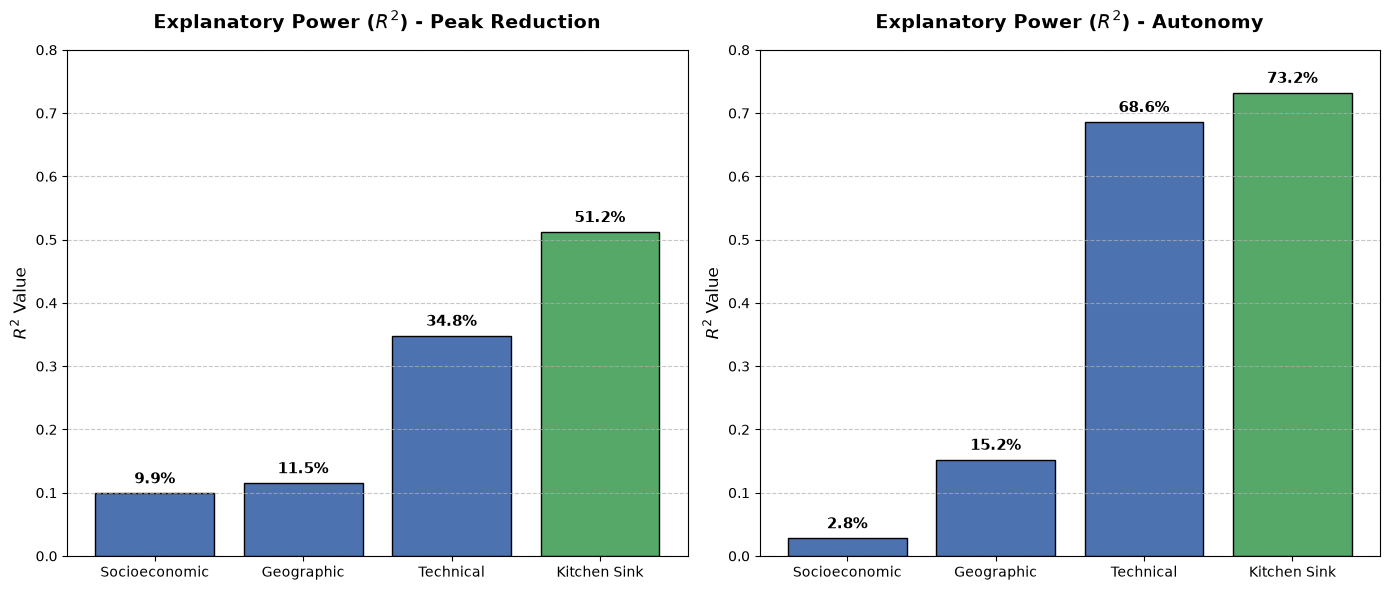

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Define the categories and the corresponding R-squared values
categories = ['Socioeconomic', 'Geographic', 'Technical', 'Kitchen Sink']

# R-squared values extracted from the regression results
r2_peak = [0.099, 0.115, 0.348, 0.512]
r2_autonomy = [0.028, 0.152, 0.686, 0.732]

# Set up the figure and axes (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Define colors: standard color for individual categories, distinct color for Kitchen Sink
colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#55A868']

# --- Plot 1: Peak Reduction ---
bars1 = ax1.bar(categories, r2_peak, color=colors, edgecolor='black')
ax1.set_title('Explanatory Power ($R^2$) - Peak Reduction', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('$R^2$ Value', fontsize=12)
ax1.set_ylim(0, 0.8) # Keep y-axis consistent across both charts
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Plot 2: Autonomy (Outage Reduction) ---
bars2 = ax2.bar(categories, r2_autonomy, color=colors, edgecolor='black')
ax2.set_title('Explanatory Power ($R^2$) - Autonomy', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('$R^2$ Value', fontsize=12)
ax2.set_ylim(0, 0.8) # Keep y-axis consistent across both charts
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Adjust layout and display
plt.tight_layout()
plt.show()

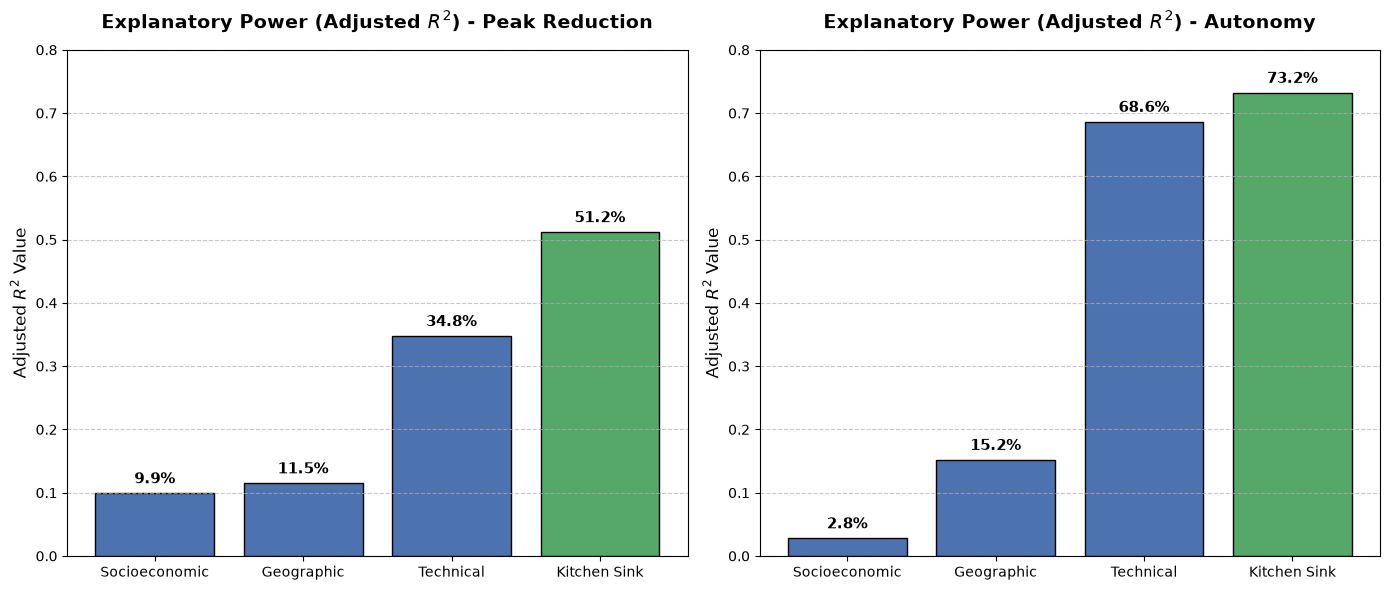

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Define the categories and the corresponding Adjusted R-squared values
categories = ['Socioeconomic', 'Geographic', 'Technical', 'Kitchen Sink']

# Adjusted R-squared values extracted directly from the regression results
adj_r2_peak = [0.0991, 0.1148, 0.3476, 0.5118]
adj_r2_autonomy = [0.0279, 0.1518, 0.6862, 0.7320]

# Set up the figure and axes (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Define colors: standard color for individual categories, distinct color for Kitchen Sink
colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#55A868']

# --- Plot 1: Peak Reduction ---
bars1 = ax1.bar(categories, adj_r2_peak, color=colors, edgecolor='black')
ax1.set_title('Explanatory Power (Adjusted $R^2$) - Peak Reduction', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Adjusted $R^2$ Value', fontsize=12)
ax1.set_ylim(0, 0.8) # Keep y-axis consistent across both charts
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Plot 2: Autonomy (Outage Reduction) ---
bars2 = ax2.bar(categories, adj_r2_autonomy, color=colors, edgecolor='black')
ax2.set_title('Explanatory Power (Adjusted $R^2$) - Autonomy', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Adjusted $R^2$ Value', fontsize=12)
ax2.set_ylim(0, 0.8) # Keep y-axis consistent across both charts
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Adjust layout and display
plt.tight_layout()
plt.show()